In [1]:
import pandas as pd
import glob 
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy

## KS Test

In [2]:
features_name = ['j_m',
 'h_m',
 'ks_m',
 'phot_g_mean_mag',
 'phot_bp_mean_mag',
 'phot_rp_mean_mag',
 'j_m-h_m',
 'j_m-ks_m',
 'j_m-phot_g_mean_mag',
 'j_m-phot_bp_mean_mag',
 'j_m-phot_rp_mean_mag',
 'h_m-ks_m',
 'h_m-phot_g_mean_mag',
 'h_m-phot_bp_mean_mag',
 'h_m-phot_rp_mean_mag',
 'ks_m-phot_g_mean_mag',
 'ks_m-phot_bp_mean_mag',
 'ks_m-phot_rp_mean_mag',
 'phot_g_mean_mag-phot_bp_mean_mag',
 'phot_g_mean_mag-phot_rp_mean_mag',
 'phot_bp_mean_mag-phot_rp_mean_mag',
 'parallax_error',
 'parallax_over_error',
 'parallax',
 'pmra',
 'pmdec',
 'pmdec_error',
 'pmra_error',
 'astrometric_sigma5d_max',
 'astrometric_excess_noise',
 'ruwe',
 'astrometric_gof_al',
 'ipd_gof_harmonic_amplitude',
 'astrometric_excess_noise_sig']

In [3]:
df = pd.read_csv("/home/nicolas/nico/git/OB-stars/data_before_KS_test.csv")


/tmp/ipykernel_21760/2726392362.py:1: DtypeWarning: Columns (49,50,51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/home/nicolas/nico/git/OB-stars/data_before_KS_test.csv")


In [4]:
skiff = df.loc[df["label"].notna()]

In [5]:
from scipy import stats

In [6]:
mag_list = []
distance_list = []
feature_list = []
for mag in [10,11,12,13,14,15]:
    for feature in features_name:
        df_mag_costrain = df.loc[df['phot_g_mean_mag']<=mag]
        skiff = df_mag_costrain[df_mag_costrain["label"].notna()]
        distance = stats.wasserstein_distance(df_mag_costrain[feature],skiff[feature])
        mag_list.append(mag)
        distance_list.append(distance)
        feature_list.append(feature)


KeyboardInterrupt: 

In [296]:

df_final = pd.DataFrame()

for feature in features_name:
    df_variable = pd.DataFrame()
    mag_list = []
    distance_mean = []
    distance_std = []
    
    for mag in [10,11,12,13,14,15]:
        distance_subsample = []
        for i in range(20):
            df_mag_costrain = df.loc[df['phot_g_mean_mag']<=mag].reset_index(drop=True)
            skiff = df_mag_costrain[df_mag_costrain["label"].notna()]
            index_1 = np.random.uniform(df_mag_costrain.index.min(), df_mag_costrain.index.max() - 1, len(skiff))
            df_mag_costrain = df_mag_costrain.iloc[index_1].reset_index(drop=True)
            distance = stats.wasserstein_distance(df_mag_costrain[feature],skiff[feature])
            distance_subsample.append(distance)
        mag_list.append(mag)
        distance_mean.append(np.mean(distance_subsample))
        distance_std.append(np.std(distance_subsample))
    df_variable["distance_mean"] = distance_mean
    df_variable["distance_std"] = distance_std
    df_variable["feature"] = feature
    df_final = pd.concat([df_final,df_variable])

KeyboardInterrupt: 

In [298]:
base = [10, 11, 12, 13, 14, 15]
repeated = list(itertools.islice(itertools.cycle(base), len(df_final)))
df_final["mag"] = repeated

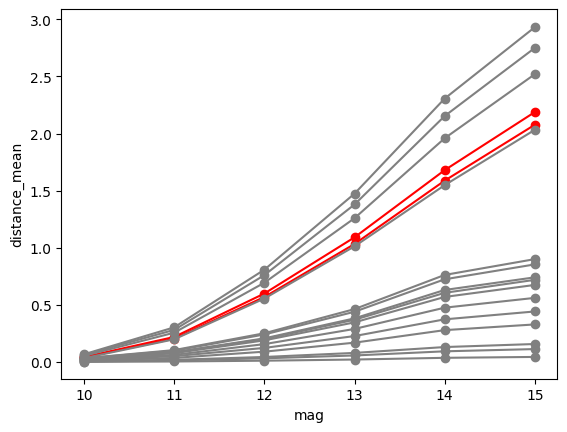

In [299]:
for key, grp in df_final.groupby("feature"):
    color = "red" if key in ["parallax_over_error", "parallax", "j_m", "h_m"] else "grey"
    plt.errorbar(x=grp["mag"], y=grp["distance_mean"], yerr=grp["distance_std"], fmt='o-', color=color)

plt.xlabel("mag")
plt.ylabel("distance_mean")
plt.show()

In [8]:
df_final = pd.DataFrame()

for feature in features_name:
    df_variable = pd.DataFrame()
    mag_list = []
    distance_mean = []
    
    for mag in [10,11,12,13,14,15]:
        df_mag_costrain = df.loc[df['phot_g_mean_mag']<=mag].reset_index(drop=True)
        skiff = df_mag_costrain[df_mag_costrain["label"].notna()]
        distance = stats.wasserstein_distance(df_mag_costrain[feature],skiff[feature])
        mag_list.append(mag)
        distance_mean.append(distance)
    df_variable["distance_mean"] = distance_mean
    df_variable["feature"] = feature
    df_final = pd.concat([df_final,df_variable])

In [10]:
import itertools
base = [10, 11, 12, 13, 14, 15]
repeated = list(itertools.islice(itertools.cycle(base), len(df_final)))
df_final["mag"] = repeated

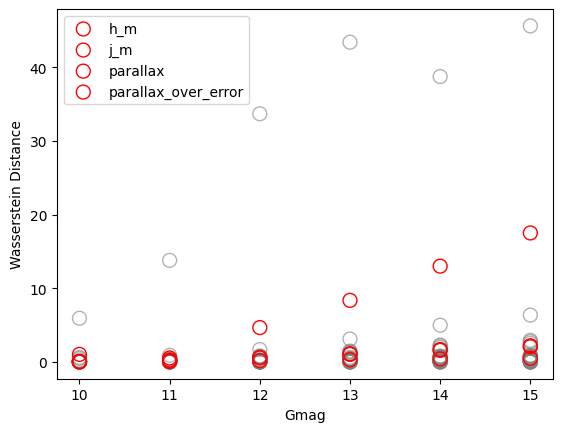

In [11]:
z_order_gray = 0
z_order_red = 100
for key, grp in df_final.groupby("feature"):
    if key in ["parallax_over_error", "parallax", "j_m", "h_m"]:
        color = "red"
        alpha = 1
        z_order_red -= 1
        z = z_order_red
        label = key
    else:
        color = "grey"
        alpha = 0.6
        z_order_gray += 1
        z = z_order_gray
        label = None

    plt.scatter(grp["mag"], grp["distance_mean"], facecolors='none', edgecolors=color, alpha=alpha, zorder=z,s=100,label=label)

plt.legend()
plt.xlabel("Gmag")
plt.ylabel("Wasserstein Distance")
plt.show()


In [12]:
from sklearn.preprocessing import MinMaxScaler

In [13]:
scaler = MinMaxScaler()

In [14]:
df_final["distance_norm"] = df_final.groupby("mag")["distance_mean"].transform(
    lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten()
)

In [ ]:
#New_names_mag_features = [
#    r"$J$",
#    r"$H$",
#    r"$K_{s}$",
#    r"$G$",
#    r"$G_{BP}$",
#    r"$G_{RP}$"
#]

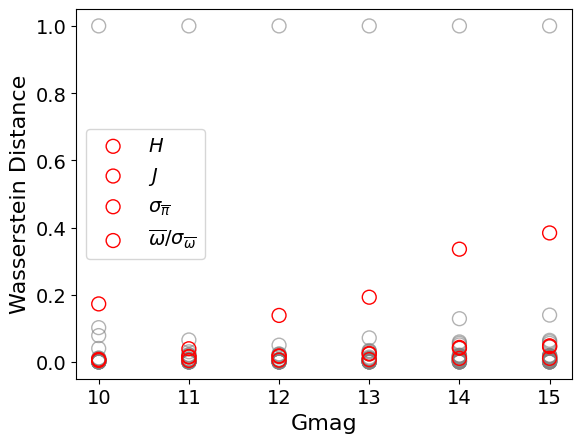

In [18]:
legend_labels = {
    "parallax_over_error": r"$\overline{\omega}/\sigma_{\overline{\omega}}$",
    "parallax": r"$\sigma_{\overline{\pi}}$",
    "j_m": r"$J$",
    "h_m": r"$H$"
}

z_order_gray = 0
z_order_red = 100
for key, grp in df_final.groupby("feature"):
    if key in legend_labels:
        color = "red"
        alpha = 1
        z_order_red -= 1
        z = z_order_red
        label = legend_labels[key]
    else:
        color = "grey"
        alpha = 0.6
        z_order_gray += 1
        z = z_order_gray
        label = None

    plt.scatter(grp["mag"], grp["distance_norm"], facecolors='none', edgecolors=color, alpha=alpha, zorder=z, s=100, label=label)

plt.legend(fontsize=14)
plt.xlabel("Gmag", fontsize=16)
plt.ylabel("Wasserstein Distance", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.savefig("WassertsteinDistance.pdf",dpi=300,
            bbox_inches="tight")  


In [17]:
skiff =skiff.reset_index(drop=True)

In [61]:
import seaborn as sns

palette = sns.color_palette("tab10")
blue = palette[0]  
naranja = palette[1]

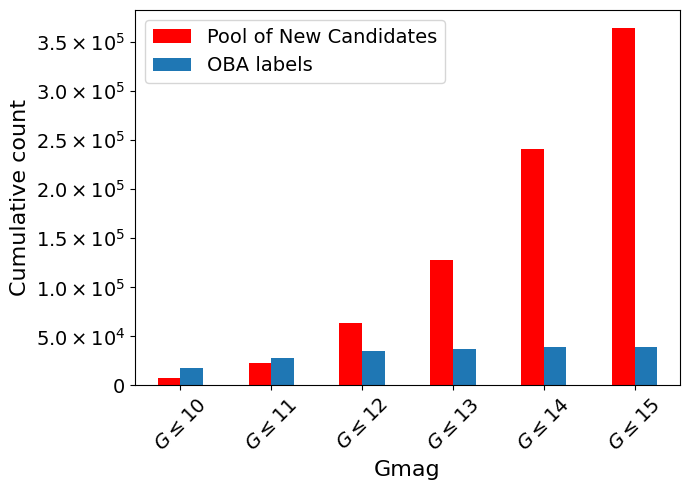

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Definir los bins
bins = [0, 10, 11, 12, 13, 14, 15]
df["phot_g_mean_mag_bin"] = pd.cut(df["phot_g_mean_mag"], bins=bins, right=True)
skiff["phot_g_mean_mag_bin"] = pd.cut(skiff["phot_g_mean_mag"], bins=bins, right=True)

# Calcular conteos acumulativos
cumulative_counts_df = df["phot_g_mean_mag_bin"].value_counts(sort=False).cumsum()
cumulative_counts_skiff = skiff["phot_g_mean_mag_bin"].value_counts(sort=False).cumsum()

# Combinar en un DataFrame
cumulative_df = pd.DataFrame({
    'OBA labels': cumulative_counts_skiff,
    'OBA GDR3': cumulative_counts_df
})

cumulative_df["Pool of New Candidates"] = cumulative_df["OBA GDR3"] - cumulative_df['OBA labels'] 

fig, ax = plt.subplots(figsize=(7, 5))  # Cuadrado
cumulative_df[["Pool of New Candidates", 'OBA labels']].plot(
    kind='bar', color=['red',blue], ax=ax
)

ax.set_xlabel('Gmag', fontsize=16)
ax.set_ylabel('Cumulative count', fontsize=16)

ax.set_xticks(range(len(cumulative_df)))
ax.set_xticklabels(
    [r"$G \leq 10$", r"$G \leq 11$", r"$G \leq 12$", r"$G \leq 13$", r"$G \leq 14$", r"$G \leq 15$"],
    rotation=45, fontsize=14
)
ax.tick_params(axis='y', labelsize=14)
ax.legend(fontsize=14)

# Formato científico estilo paper (ej. 1×10⁵)
def scientific_formatter(x, _):
    if x == 0:
        return "0"
    exp = int(np.floor(np.log10(abs(x))))
    coeff = x / 10**exp
    return rf"${coeff:.1f} \times 10^{{{exp}}}$"

import numpy as np
ax.yaxis.set_major_formatter(FuncFormatter(scientific_formatter))

plt.tight_layout()
plt.savefig("CumulativeCounts.pdf",dpi=300,
            bbox_inches="tight")  



In [53]:
import seaborn as sns
sns.color_palette("deep")[0]      # devuelve (0.298039..., 0.447058..., 0.690196...)


(0.2980392156862745, 0.4470588235294118, 0.6901960784313725)

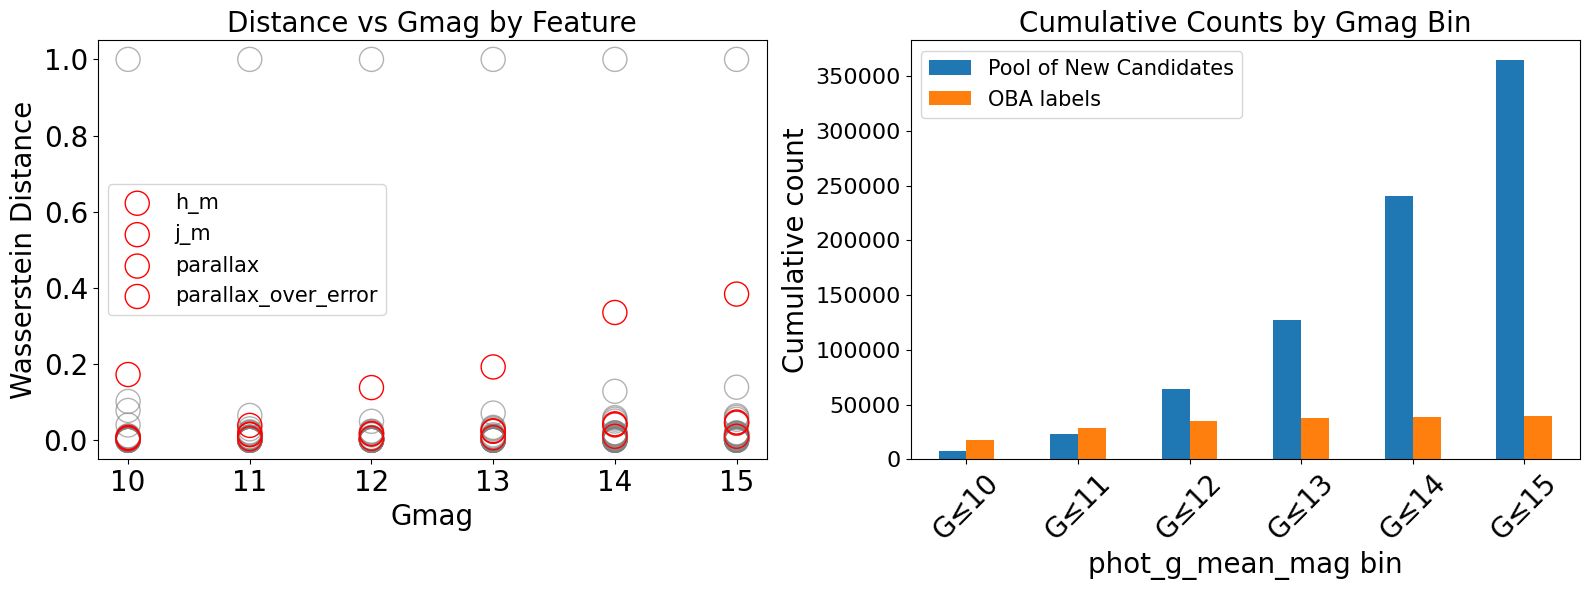

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Crear la figura y los ejes
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # Aumentar el tamaño de la figura

# -------- PRIMER PLOT: scatter por feature --------
z_order_gray = 0
z_order_red = 100

for key, grp in df_final.groupby("feature"):
    if key in ["parallax_over_error", "parallax", "j_m", "h_m"]:
        color = "red"
        alpha = 1
        z_order_red -= 1
        z = z_order_red
        label = key
    else:
        color = "grey"
        alpha = 0.6
        z_order_gray += 1
        z = z_order_gray
        label = None

    axes[0].scatter(grp["mag"], grp["distance_norm"], facecolors='none', edgecolors=color,
                    alpha=alpha, zorder=z, s=300, label=label)

axes[0].legend(fontsize=15)
axes[0].set_xlabel("Gmag", fontsize=20)
axes[0].set_ylabel("Wasserstein Distance", fontsize=20)
axes[0].set_title("Distance vs Gmag by Feature", fontsize=20)
axes[0].tick_params(axis='both', labelsize=20)

# -------- SEGUNDO PLOT: barras acumulativas --------
# Definir los bins
bins = [0, 10, 11, 12, 13, 14, 15]
df["phot_g_mean_mag_bin"] = pd.cut(df["phot_g_mean_mag"], bins=bins, right=True)
skiff["phot_g_mean_mag_bin"] = pd.cut(skiff["phot_g_mean_mag"], bins=bins, right=True)

# Calcular conteos acumulativos
cumulative_counts_df = df["phot_g_mean_mag_bin"].value_counts(sort=False).cumsum()
cumulative_counts_skiff = skiff["phot_g_mean_mag_bin"].value_counts(sort=False).cumsum()

# Combinar en un DataFrame
cumulative_df = pd.DataFrame({
    'OBA labels': cumulative_counts_skiff,
    'OBA GDR3': cumulative_counts_df
})

cumulative_df["Pool of New Candidates"] = cumulative_df["OBA GDR3"] - cumulative_df['OBA labels']

# Plot de barras
cumulative_df[["Pool of New Candidates", 'OBA labels']].plot(kind='bar', ax=axes[1])

axes[1].set_xlabel('phot_g_mean_mag bin', fontsize=20)
axes[1].set_ylabel('Cumulative count', fontsize=20)
axes[1].set_title('Cumulative Counts by Gmag Bin', fontsize=20)
axes[1].set_xticks(range(len(cumulative_df)))
axes[1].set_xticklabels(["G≤10", "G≤11", "G≤12", "G≤13", "G≤14", "G≤15"], rotation=45, fontsize=20)
axes[1].tick_params(axis='y', labelsize=16)
axes[1].legend(fontsize=15)

plt.tight_layout()
plt.show()


In [131]:
feature = "parallax_over_error"
mag_list = []
distance_mean_nd = []
distance_std_nd = []

distance_mean_1d = []
distance_std_1d = []

for mag in [10,11,12,13,14,15]:
    distance_subsample_nd = []
    distance_subsample_1d = []
    for i in range(50):
        df_mag_costrain = df.loc[df['phot_g_mean_mag']<=mag].reset_index(drop=True)
        skiff = df_mag_costrain[df_mag_costrain["label"].notna()].reset_index(drop=True)
        index_1 = np.random.uniform(df_mag_costrain.index.min(), df_mag_costrain.index.max() - 1, 50)
        index_2 = np.random.uniform(skiff.index.min(), skiff.index.max() - 1, 50)
        df_mag_costrain = df_mag_costrain.iloc[index_1].reset_index(drop=True)
        skiff = skiff.iloc[index_2].reset_index(drop=True)
        distance_nd = stats.wasserstein_distance_nd(df_mag_costrain[feature].values.reshape(-1,1),skiff[feature].values.reshape(-1,1))
        distance_1d = stats.wasserstein_distance(df_mag_costrain[feature].values,skiff[feature].values)
        distance_subsample_nd.append(distance_nd)
        distance_subsample_1d.append(distance_1d)
    distance_mean_nd.append(np.mean(distance_subsample_nd))
    distance_std_nd.append(np.std(distance_subsample_nd))
    
    distance_mean_1d.append(np.mean(distance_subsample_1d))
    distance_std_1d.append(np.std(distance_subsample_1d))

In [116]:
df_1d_test = df_final.loc[df_final["feature"]=="parallax_over_error"]

In [134]:
distance_std_nd

[np.float64(2.788874413704507),
 np.float64(2.7192789207690313),
 np.float64(2.9819523345440295),
 np.float64(2.7155028187266286),
 np.float64(3.5211686095989125),
 np.float64(4.507849776082057)]

In [133]:
distance_std_1d

[np.float64(2.788874413704507),
 np.float64(2.719278920769031),
 np.float64(2.98195233454403),
 np.float64(2.715502818726629),
 np.float64(3.5211686095989116),
 np.float64(4.5078497760820575)]

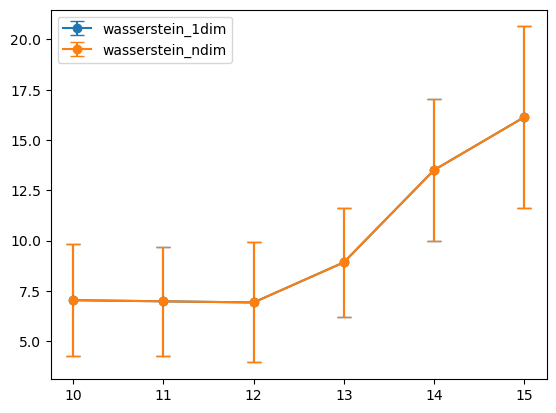

In [132]:
x = [10, 11, 12, 13, 14, 15]
y = distance_mean
plt.errorbar(x, distance_mean_1d, yerr=distance_std_1d, fmt='o-', capsize=5,label="wasserstein_1dim")
plt.errorbar(x, distance_mean_nd, yerr=distance_std_nd, fmt='o-', capsize=5,label="wasserstein_ndim")
plt.legend()

### cargar el random forest

In [1]:
import matplotlib.pyplot as plt

In [2]:
features_name = ['j_m',
 'h_m',
 'ks_m',
 'phot_g_mean_mag',
 'phot_bp_mean_mag',
 'phot_rp_mean_mag',
 'j_m-h_m',
 'j_m-ks_m',
 'j_m-phot_g_mean_mag',
 'j_m-phot_bp_mean_mag',
 'j_m-phot_rp_mean_mag',
 'h_m-ks_m',
 'h_m-phot_g_mean_mag',
 'h_m-phot_bp_mean_mag',
 'h_m-phot_rp_mean_mag',
 'ks_m-phot_g_mean_mag',
 'ks_m-phot_bp_mean_mag',
 'ks_m-phot_rp_mean_mag',
 'phot_g_mean_mag-phot_bp_mean_mag',
 'phot_g_mean_mag-phot_rp_mean_mag',
 'phot_bp_mean_mag-phot_rp_mean_mag',
 'parallax_error',
 'parallax_over_error',
 'parallax',
 'pmra',
 'pmdec',
 'pmdec_error',
 'pmra_error',
 'astrometric_sigma5d_max',
 'astrometric_excess_noise',
 'ruwe',
 'astrometric_gof_al',
 'ipd_gof_harmonic_amplitude',
 'astrometric_excess_noise_sig']

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

class DataFrameScaler:
    def __init__(self):
        self.scalers = {}

    def scale(self, df):
        """
        Escala las columnas del DataFrame a media 0 y desviación estándar 1.
        """
        scaled_df = df.copy()
        for column in df.columns:
            scaler = StandardScaler()
            scaled_df[column] = scaler.fit_transform(df[column].values.reshape(-1, 1)).flatten()
            self.scalers[column] = scaler
        return scaled_df

    def inverse_scale(self, df):
        """
        Devuelve el DataFrame escalado a su estado original.
        """
        original_df = df.copy()
        for column in df.columns:
            scaler = self.scalers.get(column)
            if scaler:
                original_df[column] = scaler.inverse_transform(df[column].values.reshape(-1, 1)).flatten()
        return original_df

    def scale_new_feature(self, df_subset):
        """
        Escala un subconjunto de columnas usando escaladores ya entrenados.
        """
        scaled_df = df_subset.copy()
        for column in df_subset.columns:
            scaler = self.scalers.get(column)
            if not scaler:
                raise ValueError(f"No trained scaler found for column '{column}'")
            scaled_df[column] = scaler.transform(df_subset[column].values.reshape(-1, 1)).flatten()
        return scaled_df



In [4]:
import joblib


# Cargar el modelo Random Forest guardado
modelo_rf = joblib.load("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/skiff_rf.sav")

In [5]:
scaler = DataFrameScaler()

In [6]:
df = pd.read_csv("/home/nicolas/nico/git/OB-stars/data_before_KS_test.csv")

/tmp/ipykernel_234948/387778151.py:1: DtypeWarning: Columns (49,50,51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/home/nicolas/nico/git/OB-stars/data_before_KS_test.csv")


In [7]:
df_brights = df.loc[df["phot_g_mean_mag"]<=12].reset_index(drop=True)

In [8]:
df_brights[features_name] = scaler.scale(df_brights[features_name])


In [9]:
df_X = df[features_name].reset_index(drop=True)

In [10]:
df_X[features_name] = scaler.scale_new_feature(df_X[features_name])


In [11]:
new_columns = [
    'Jmag', 'Hmag', 'Ksmag', 'Gmag', 'BPmag', 'RPmag',
    'Jmag-Hmag', 'Jmag-Ksmag', 'Jmag-Gmag', 'Jmag-BPmag', 'Jmag-RPmag',
    'Hmag-Ksmag', 'Hmag-Gmag', 'Hmag-BPmag', 'Hmag-RPmag',
    'Ksmag-Gmag', 'Ksmag-BPmag', 'Ksmag-RPmag', 'Gmag-BPmag', 'Gmag-RPmag',
    'BPmag-RPmag', 'Parallax_error', 'Parallax_over_error', 'Parallax',
    'pmRA', 'pmDEC', 'pmDEC_error', 'pmRA_error', 'Sigma5d_max',
    'Excess_noise', 'RUWE', 'Gof_al', 'Ipd_gof_harmonic_amplitude', 'Excess_noise_sig'
]

# Renombrar columnas del DataFrame df
df_X.columns = new_columns

In [14]:
result = modelo_rf.predict_proba(df_X[modelo_rf.feature_names_in_])

In [15]:
df["predic"] = result[:,1]

In [36]:
df_antiguo = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data.csv")

/tmp/ipykernel_234948/32864098.py:1: DtypeWarning: Columns (49,50,51,52,72) have mixed types. Specify dtype option on import or set low_memory=False.
  df_antiguo = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data.csv")


In [78]:
check = df.merge(df_antiguo[["source_id","B2_cut_probability"]],how="inner")

Text(0.5, 1.0, 'Misma prediccion en el Paper')

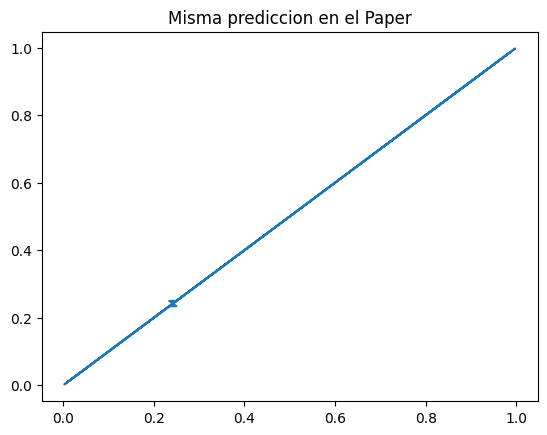

In [79]:
plt.plot(check["B2_cut_probability"],check["predic"])
plt.title("Misma prediccion en el Paper")

In [82]:
df_fainter = df.loc[(df["predic"]>0.6)&(df["phot_g_mean_mag"]>12)].reset_index(drop=True)

In [85]:
print(f"Tenemos estos candidatos debiles {len(df_fainter)}")

Tenemos estos candidatos debiles 120345


In [88]:
df_fainter_4LAMOST = df_fainter[["ra","dec"]]

In [90]:
df_fainter_4LAMOST["radio"] = 5

/tmp/ipykernel_7334/2684083765.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fainter_4LAMOST["radio"] = 5


In [92]:
df_fainter_4LAMOST.to_csv("df_fainter_4LAMOST.csv",index=False,header=None)

In [ ]:
# Reentrenar pero ahora con B3

In [15]:
from imblearn.ensemble import BalancedRandomForestClassifier

# Supongamos que modelo_rf es tu modelo actual de tipo BalancedRandomForestClassifier
params = modelo_rf.get_params()

# Crear un nuevo BRF con los mismos parámetros
nuevo_brf = BalancedRandomForestClassifier(**params)

In [ ]:
nuevo_brf

In [27]:
labels = df_brights.loc[df_brights["label"].notna()].reset_index(drop=True)

In [28]:
labels.loc[labels['label']<=1.3,'B3'] = 1
labels.loc[labels['label']>1.3,'B3'] = 0

In [30]:
X = labels[features_name]
y = labels['B3']

In [31]:
nuevo_brf.fit(X,y)

BalancedRandomForestClassifier(max_depth=30, max_features='log2',
                               n_estimators=1200, replacement=True,
                               sampling_strategy='majority')

In [34]:
df_brights["predict"] = nuevo_brf.predict_proba(df_brights[features_name])[:,1]


In [41]:
df_antiguo = df_antiguo.merge(df_brights[["index","predict"]])

In [47]:
df_antiguo = df_antiguo.loc[df_antiguo["B2_cut_split"].isna()]

In [64]:
df_antiguo.loc[(df_antiguo["B2_cut_probability"]>0.6)]

,index,source_id,ra,dec,ra_error,dec_error,Parallax,Parallax_error,Parallax_over_error,pmRA,...,Ksmag-BPmag,Ksmag-RPmag,Gmag-BPmag,Gmag-RPmag,BPmag-RPmag,bp_rp,B2,B2_cut_split,B2_cut_probability,predict
35469,57,6056404410010181888,193.446857,-60.372235,0.010233,0.011742,0.485992,0.016196,30.007717,-4.726398,...,-1.350078,-0.910345,-0.139957,0.299776,0.439733,0.299776,NaN,NaN,0.801667,0.887500
35471,78,5548252295022221440,122.773256,-31.270177,0.010242,0.011390,0.223595,0.015097,14.810351,-2.691090,...,-0.181691,0.001466,-0.042333,0.140824,0.183157,0.140824,NaN,NaN,0.645000,0.706667
35472,89,4067518953423901568,269.773997,-24.435101,0.015131,0.012173,0.336776,0.016081,20.942917,0.373542,...,-2.553498,-1.396665,-0.485353,0.671480,1.156833,0.671480,NaN,NaN,0.743333,0.708333
35475,185,2182012333201634304,311.393040,51.550021,0.014557,0.015758,0.558750,0.017105,32.665325,-2.174443,...,-0.888800,-0.394564,-0.174390,0.319846,0.494236,0.319846,NaN,NaN,0.773333,0.772500
35483,511,458308955066917120,35.298325,56.853907,0.013860,0.016497,0.388412,0.025166,15.433717,-0.632541,...,-0.520022,-0.196582,-0.062527,0.260912,0.323440,0.260912,NaN,NaN,0.943333,0.957500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99380,1090707,5852268497137570304,208.378431,-64.470820,0.008772,0.009906,0.248054,0.014103,17.588459,-6.577054,...,-1.895254,-0.922230,-0.391606,0.581418,0.973024,0.581418,NaN,NaN,0.960833,0.963994
99382,1090734,5337709802751076608,167.045154,-60.246386,0.013423,0.012417,0.607679,0.015017,40.466816,-6.604736,...,-1.580618,-0.834572,-0.271290,0.474756,0.746046,0.474756,NaN,NaN,0.764167,0.621667
99385,1090787,5864090957158292352,203.339627,-64.428129,0.011969,0.013909,0.140483,0.017663,7.953494,-6.599529,...,-1.109537,-0.564549,-0.192714,0.352274,0.544988,0.352274,NaN,NaN,0.783333,0.785000
99386,1090807,458308469733215488,35.288818,56.816726,0.012023,0.015792,0.459138,0.022097,20.778366,-0.777010,...,-0.389914,-0.136988,-0.065204,0.187722,0.252926,0.187722,NaN,NaN,0.907500,0.920000


1968

In [76]:
len(df_antiguo.loc[(df_antiguo["B2_cut_probability"]<=0.6)&(df_antiguo["predict"]>0.7)])/len(df_antiguo.loc[df_antiguo["B2_cut_probability"]>0.6])

0.023764990648036086

In [ ]:
Si cambiamos la definicion de estrella masiva en B3 seremos mas permisivo con la clase early type. Realizamos una prueba entrenando un nuevo BRF utilizando los hyper parametros del modelo anterior
Esto nos permitiria aumentar la muestra en 20% estrellas, no obstante solamente un 2% tiene una probabilidad mayor a 0.7
con lo cual aumentaremos el numero de moderate probability pero no hay un aumento significativo para high probability

### Revisar line 449: what about other labels not considered in the training (eg WR, PN, SN) ?

In [228]:
import ast
coded_alonso = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/OBAGDR3_2arcsecSkiff_grouped_sd_3_without_OB_without_non_consec_lum.csv")
coded_alonso['source_id'] = coded_alonso['source_id'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else x)
coded_alonso["source_id_list"] = coded_alonso["source_id"]
coded_alonso = coded_alonso.explode("source_id",ignore_index=True)
coded_alonso["source_id"] = coded_alonso["source_id"].astype(int)

/tmp/ipykernel_56114/2021166882.py:2: DtypeWarning: Columns (1,2,9) have mixed types. Specify dtype option on import or set low_memory=False.
  coded_alonso = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/OBAGDR3_2arcsecSkiff_grouped_sd_3_without_OB_without_non_consec_lum.csv")


In [230]:
coded_alonso.keys()

Index(['Unnamed: 0', 'original_skiff_ID', 'source_id', 'Bibcode', 'ra_mean',
       'dec_mean', 'skiff_type', 'GroupID_skiff', 'GroupSize_skiff',
       'Sep_skiff', 'type_codification_mean', 'lum_codification_mean',
       'is_binary', 'no_subtype', 'subtype_range', 'uncodifiable_type',
       'no_lum_class', 'lum_class_range', 'lum_class_range_non_consecutive',
       'lum_class_range_uncertain', 'uncodifiable_lum_class', 'is_OB', 'is_WD',
       'is_WR', 'is_PN', 'is_C', 'is_S', 'pec_uncertain', 'pec_misc',
       'pec_broadening', 'pec_emission', 'pec_NC', 'is_BpHgMn', 'is_OfWN',
       'is_OIafpe', 'is_OBe', 'is_Ofp', 'should_be_excluded', 'index',
       'type_codification_sd', 'lum_codification_sd', 'source_id_list'],
      dtype='object')

In [231]:
df = df.merge(coded_alonso,how="left",on="source_id")

In [237]:
df.keys()

Index(['index_x', 'source_id', 'ra', 'dec', 'ra_error', 'dec_error',
       'Parallax', 'Parallax_error', 'Parallax_over_error', 'pmRA',
       ...
       'is_BpHgMn', 'is_OfWN', 'is_OIafpe', 'is_OBe', 'is_Ofp',
       'should_be_excluded', 'index_y', 'type_codification_sd',
       'lum_codification_sd', 'source_id_list_y'],
      dtype='object', length=115)

In [238]:
df.loc[df["is_PN"]==1].drop_duplicates(subset="source_id")

,index_x,source_id,ra,dec,ra_error,dec_error,Parallax,Parallax_error,Parallax_over_error,pmRA,...,is_BpHgMn,is_OfWN,is_OIafpe,is_OBe,is_Ofp,should_be_excluded,index_y,type_codification_sd,lum_codification_sd,source_id_list_y
482,607301,196996680850087936,89.099549,46.104741,0.028814,0.027730,0.535202,0.037230,14.375578,-6.115103,...,0.0,0.0,0.0,0.0,0.0,0.0,7583.0,1.683251,NaN,"[196996680850087936, 196996680850087936, 19699..."
53001,1037462,5306043043221261568,145.856752,-57.282071,0.011563,0.010940,0.245541,0.012551,19.563622,-5.869025,...,0.0,0.0,0.0,0.0,0.0,0.0,13727.0,0.577350,0.57735,"[5306043043221261568, 5306043043221261568, 530..."
126159,1089391,5524114505786772992,132.162697,-42.898314,0.060344,0.067419,0.477044,0.076230,6.257968,-5.555295,...,0.0,0.0,0.0,0.0,0.0,0.0,23911.0,NaN,NaN,"[5524114505786772992, 5524114505786772992]"


In [236]:
df.loc[df["is_WR"]==1].drop_duplicates(subset="source_id")

,index_x,source_id,ra,dec,ra_error,dec_error,Parallax,Parallax_error,Parallax_over_error,pmRA,...,is_BpHgMn,is_OfWN,is_OIafpe,is_OBe,is_Ofp,should_be_excluded,index_y,type_codification_sd,lum_codification_sd,source_id_list_y
708,1087214,5964124353254695936,253.776874,-44.989276,0.053095,0.037804,0.568614,0.064687,8.790280,-0.182169,...,0.0,0.0,0.0,0.0,0.0,0.0,23513.0,1.623303,0.5,"[5964124353254695936, 5964124353254695936, 596..."
4822,816363,5351436861801458944,158.008192,-58.228348,0.013206,0.012752,0.338801,0.015089,22.453003,-7.125746,...,0.0,0.0,0.0,0.0,0.0,0.0,10236.0,1.608415,0.0,"[5351436861801458944, 5351436861801458944, 535..."
105642,781723,5934367136201757824,246.780983,-51.422952,0.014737,0.010643,0.780745,0.019220,40.621050,-0.310389,...,0.0,0.0,0.0,0.0,0.0,0.0,9902.0,0.000000,NaN,"[5934367136201757824, 5934367136201757824, 593..."


### Models SED

In [3]:
import pandas as pd

In [4]:
column_names = [
    "Object", "RA", "DEC", "D (pc)", "Model", "mfid", "Teff", "logg", "Meta.",
    "more", "Chi2", "Md", "Ftot", "Ferr", "Fobs/Ftot", "Lbol", "Lberr", "MaxLam",
    "Nfit", "Ntot", "Av", "e_Teff", "e_logg", "e_Meta.", "Teff_min", "Teff_max",
    "logg_min", "logg_max", "Meta_min", "Meta_max", "excfit", "err_Av", "Rad1",
    "eRad1", "Rad2", "eRad2", "M1", "eM1", "M2", "eM2", "Teff_min_68cl",
    "Teff_max_68cl", "Teff_min_96cl", "Teff_max_96cl", "logg_min_68cl",
    "logg_max_68cl", "logg_min_96cl", "logg_max_96cl", "Meta_min_68cl",
    "Meta_max_68cl", "Meta_min_96cl", "Meta_max_96cl", "Av_min_68cl",
    "Av_max_68cl", "Av_min_96cl", "Av_max_96cl", "Ftot_min_68cl", "Ftot_max_68cl",
    "Ftot_min_96cl", "Ftot_max_96cl", "Vgf", "Vgfb"
]

In [5]:
df = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data.csv")
df = df.sort_values(by="B2_cut_probability",ascending=False).head(100).reset_index(drop=True)

/tmp/ipykernel_20499/69499002.py:1: DtypeWarning: Columns (49,50,51,52,72) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data.csv")


In [7]:
results_vosa = pd.read_csv("Feature_importance/Test2/vosa_results_86068/results/bestfitp.dat",comment="#",delim_whitespace=True,names=column_names)

In [10]:
results_vosa.to_csv("Feature_importance/Test2/vosa_results_86068/results/bestfitp.csv",index=False)

In [ ]:
df = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/resultados_V2/Data.csv")
df["d"] = 1000*(1/df["Parallax"])
df = df.loc[(df["d"]<1000)&(df["B2_cut_probability"]>0.9)]
df[["index","ra","dec"]].to_csv("HighProbLess1Kpc.csv",index=False)

In [26]:
df = pd.read_csv("HighProbLess1KpcVOSAresults.csv")

In [38]:
df =  df.loc[df['D (pc)'] <1000]

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

In [42]:
df = df.loc[df["Teff"]<60000]

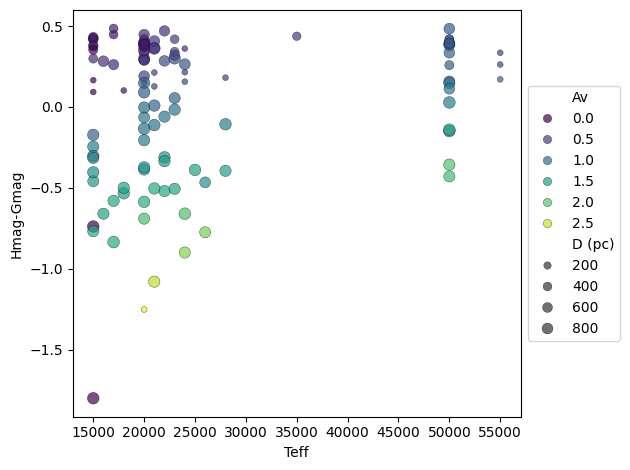

In [43]:

##Quitar paralajes negativos para el plot

sns.scatterplot(
    data=df,
    x="Teff",
    y="Hmag-Gmag",
    hue="Av",
    size='D (pc)',
   # sizes=(10, 200),      # tamaño de los puntos
    alpha=0.7,            # transparencia
    edgecolor="black",    # borde
    linewidth=0.3,        # grosor del borde
    palette="viridis"     # paleta opcional
)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()


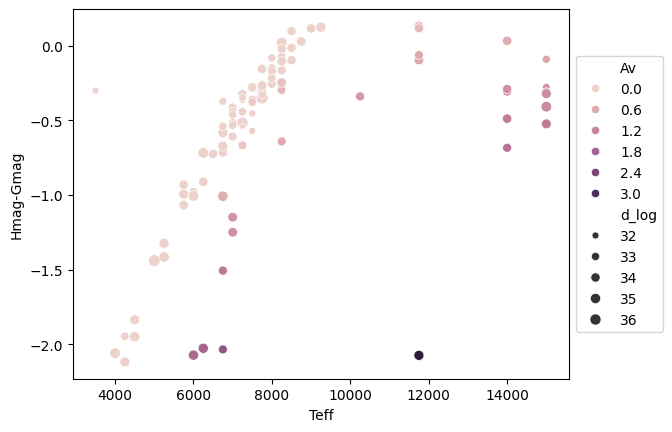

In [261]:
sns.scatterplot(data=df,x="Teff",y='Hmag-Gmag',hue='Av',size='d_log')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))


In [31]:
df["skiff_type"].str[0].unique()

array(['O', 'B', 'A', 'F', 'G', 'K', 'M', 'e', nan, 'k', 's', 'P', 'W',
       'C', 'R', 'h', 'c', 'D', '['], dtype=object)

In [38]:
df_g12 = df.loc[df["phot_g_mean_mag"]<=12]

In [49]:
df_g12_Be = df_g12.loc[df_g12["skiff_type"].str[0:2]=="Be"].reset_index(drop=True)

In [50]:
import seaborn as sns

In [80]:
df_antiguo_e = df_antiguo.loc[
    (df_antiguo["skiff_type"] == "O2e") |
    (df_antiguo["skiff_type"] == "O3e") |
    (df_antiguo["skiff_type"] == "O4e") |
    (df_antiguo["skiff_type"] == "O5e") |
    (df_antiguo["skiff_type"] == "O6e") |
    (df_antiguo["skiff_type"] == "O7e") |
    (df_antiguo["skiff_type"] == "O8e") |
    (df_antiguo["skiff_type"] == "O9e") |
    (df_antiguo["skiff_type"] == "B0e") |
    (df_antiguo["skiff_type"] == "B1e") |
    (df_antiguo["skiff_type"] == "B2e") |
    (df_antiguo["skiff_type"] == "B3e") |
    (df_antiguo["skiff_type"] == "B4e") |
    (df_antiguo["skiff_type"] == "B5e") |
    (df_antiguo["skiff_type"] == "B6e") |
    (df_antiguo["skiff_type"] == "B7e") |
    (df_antiguo["skiff_type"] == "B8e") |
    (df_antiguo["skiff_type"] == "B9e") |
    (df_antiguo["skiff_type"] == "A0e") |
    (df_antiguo["skiff_type"] == "A1e") |
    (df_antiguo["skiff_type"] == "A2e") |
    (df_antiguo["skiff_type"] == "A3e") |
    (df_antiguo["skiff_type"] == "A4e") |
    (df_antiguo["skiff_type"] == "A5e") |
    (df_antiguo["skiff_type"] == "A6e") |
    (df_antiguo["skiff_type"] == "A7e") |
    (df_antiguo["skiff_type"] == "A8e") |
    (df_antiguo["skiff_type"] == "A9e")
]


In [97]:
df_antiguo_e.loc[df_antiguo_e["skiff_type"].str[0]=="O","B2e"] = 1

/tmp/ipykernel_56114/3398104043.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_antiguo_e.loc[df_antiguo_e["skiff_type"].str[0]=="O","B2e"] = 1


In [106]:
df_antiguo_e.loc[(df_antiguo_e["skiff_type"].str[0]=="B")&
                 (df_antiguo_e["skiff_type"].str[1].astype(int) <=2),"B2e"] = 1

In [111]:
df_antiguo_e.loc[df_antiguo_e["B2e"].isna(),"B2e"] = 0

In [157]:
df_antiguo_e.loc[(df_antiguo_e["B2_cut_probability"]>0.6)&(df_antiguo_e["B2e"]==0),"metric_e"] = "FP"
df_antiguo_e.loc[(df_antiguo_e["B2_cut_probability"]<=0.6)&(df_antiguo_e["B2e"]==0),"metric_e"] = "TN"

df_antiguo_e.loc[(df_antiguo_e["B2_cut_probability"]>0.6)&(df_antiguo_e["B2e"]==1),"metric_e"] = "TP"
df_antiguo_e.loc[(df_antiguo_e["B2_cut_probability"]<=0.6)&(df_antiguo_e["B2e"]==1),"metric_e"] = "FN"

In [166]:
df_antiguo_e.groupby("metric_e").count()["index"].keys

<bound method Series.keys of metric_e
FN     9
FP    15
TN    81
TP    12
Name: index, dtype: int64>

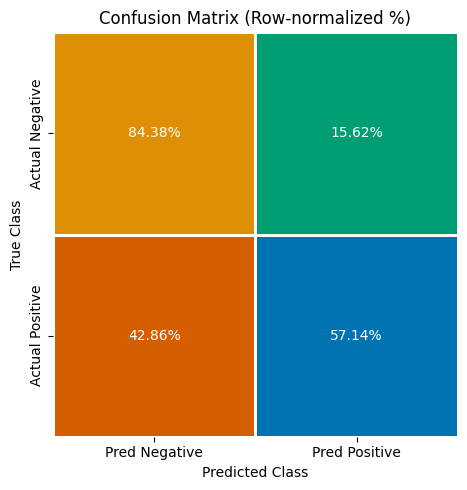

In [168]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import ListedColormap

# Valores de la matriz
TP, TN, FP, FN = 12, 81, 15, 9

# Matriz de conteo por filas: [Actual Neg], [Actual Pos]
counts = np.array([[TN, FP],
                   [FN, TP]])

# Normalización fila a fila (por clase real)
row_sums = counts.sum(axis=1, keepdims=True)
percent_matrix = counts / row_sums * 100

# Crear matriz de texto para anotaciones
cm = np.array([[f"{percent_matrix[0, 0]:.2f}%", f"{percent_matrix[0, 1]:.2f}%"],
               [f"{percent_matrix[1, 0]:.2f}%", f"{percent_matrix[1, 1]:.2f}%"]])

# Índices de colores
indices_colores = np.array([[0, 1], [2, 3]])

# Paleta de colores
colorblind_palette = sns.color_palette("colorblind", 4)
colores = [colorblind_palette[1], colorblind_palette[2],  # TN, FP
           colorblind_palette[3], colorblind_palette[0]]  # FN, TP
cmap_discreto = ListedColormap(colores)

# Etiquetas
xticklabels = ['Pred Negative', 'Pred Positive']
yticklabels = ['Actual Negative', 'Actual Positive']

# Plot
plt.figure(figsize=(6, 5))
ax = sns.heatmap(indices_colores, cmap=cmap_discreto, cbar=False, square=True,
                 linewidths=1, annot=cm, fmt='', 
                 xticklabels=xticklabels, yticklabels=yticklabels)

# Anotaciones en blanco
for text in ax.texts:
    text.set_color('white')

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix (Row-normalized %)")
plt.tight_layout()
plt.show()



In [ ]:
(TP,FP
FN,TN)

In [ ]:
(17,20)

In [130]:
# Crea una nueva columna con valores codificados: O=0, B=1, A=2 (ignorando la 'e')
df_antiguo_e["skiff_code"] = df_antiguo_e["skiff_type"].str.replace("e", "", regex=False).map(
    lambda x: 0 if x[0] == "O" else 1 if x[0] == "B" else 2
) * 10 + df_antiguo_e["skiff_type"].str[1].astype(int)


/tmp/ipykernel_56114/3085274536.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_antiguo_e["skiff_code"] = df_antiguo_e["skiff_type"].str.replace("e", "", regex=False).map(


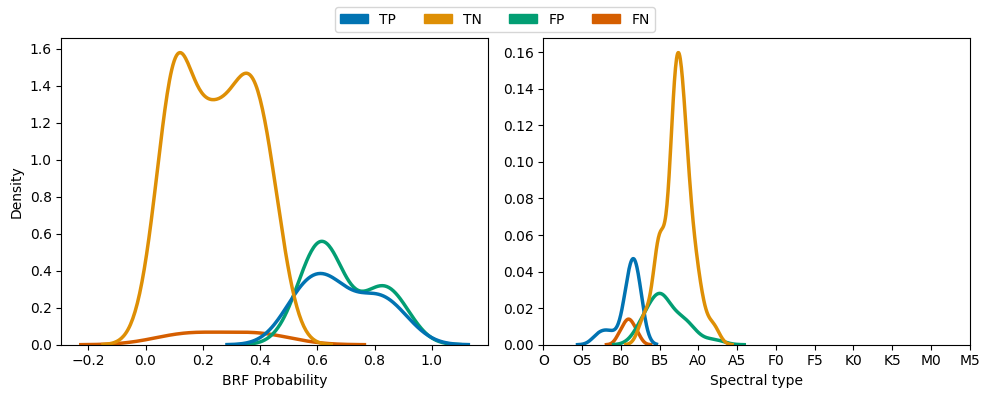

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# Crear la figura y los subplots con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Colores personalizados para los tonos
colorblind_palette = sns.color_palette("colorblind", 4)

# Asignar colores a tus categorías
palette = {'TP': colorblind_palette[0],  # primer color
           'TN': colorblind_palette[1],  # segundo color
           'FP': colorblind_palette[2],  # tercer color
           'FN': colorblind_palette[3]}  # cuarto color

# Gráfico 1 - KDE con tonos diferentes para TN, TP, FP, FN
sns.kdeplot(data=df_antiguo_e, x="B2_cut_probability", hue="metric_e", ax=axes[0], fill=False, palette=palette, linewidth=2.5)

# Gráfico 2 - KDE con tonos diferentes para TN, TP, FP, FN
sns.kdeplot(data=df_antiguo_e, x="skiff_code", hue="metric_e", ax=axes[1], fill=False, palette=palette, linewidth=2.5)

# Ajustar los ticks del eje x en el gráfico 2
tick_locations = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55]
tick_labels = ['O', 'O5', 'B0', 'B5', 'A0', 'A5', 'F0', 'F5', 'K0', 'K5', 'M0', 'M5']
axes[1].set_xticks(tick_locations)
axes[1].set_xticklabels(tick_labels)

# Etiquetas personalizadas del eje x
axes[0].set_xlabel("BRF Probability")
axes[1].set_xlabel("Spectral type")

# Ocultar las leyendas de los subplots individuales
axes[0].get_legend().remove()
axes[1].get_legend().remove()
axes[1].set_ylabel("")

# Crear handles y labels manualmente a partir de la paleta
handles = [mpatches.Patch(color=palette[key], label=key) for key in palette.keys()]

# Crear una leyenda compartida
fig.legend(handles=handles, loc='upper center', ncol=4)

# Ajustar el layout para dejar espacio para la leyenda
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Guardar y mostrar el gráfico
#plt.savefig(f'{path_plots}/metrics.pdf', bbox_inches='tight')
plt.show()


In [75]:
df_antiguo_emission  = df_antiguo.loc[
    df_antiguo["skiff_type"].str.contains(r"^(0[2-9]e|[1-9][0-9]e|A[0-9]e)$", na=False)
]

/tmp/ipykernel_56114/3097886133.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_antiguo["skiff_type"].str.contains(r"^(0[2-9]e|[1-9][0-9]e|A[0-9]e)$", na=False)


In [76]:
df_antiguo_emission["skiff_type"]

77947    A0e
96059    A0e
96081    A0e
96510    A0e
96714    A0e
97590    A2e
98972    A1e
99030    A2e
99117    A2e
Name: skiff_type, dtype: object

## Classificar fainters stars 

In [2]:
import glob
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.integrate
from scipy.optimize import curve_fit
from scipy import stats
import seaborn as sns
from astropy.io import fits
from astropy import units as u
from astropy.coordinates import SkyCoord, Angle
from astropy.wcs import WCS
from regions import CircleSkyRegion, CirclePixelRegion, RectangleSkyRegion, RectanglePixelRegion
from pandarallel import pandarallel
#from pysynphot import observation, spectrum
from matplotlib.colors import LogNorm
from sklearn.metrics import mean_squared_error
from matplotlib.backends.backend_pdf import PdfPages
from math import log
from astropy.constants import c as c_vel

from pandarallel import pandarallel

pandarallel.initialize(progress_bar=True)


def extraer_datos_fits(archivo):
    """
    Extrae informacion de un LAMOST FITS.

    Parámetros:
    - archivo (str): Ruta al archivo FITS.

    Retorna:
    - dict: Diccionario con los valores extraídos del encabezado y los datos de flujo y longitud de onda.
    """
    with fits.open(archivo) as image:
        # Extraer valores del encabezado
        snrg = image[0].header["SNRG"]
        ra_obs = image[0].header["RA_OBS"]
        dec_obs = image[0].header["DEC_OBS"]
        desig = image[0].header["DESIG"]
        helio = image[0].header["HELIO"]
        vacuum = image[0].header["VACUUM"]
        fib_mask = image[0].header["FIB_MASK"]
        helio_rv = image[0].header["HELIO_RV"]
        
        # Crear y retornar el diccionario con los datos extraídos
        return snrg, ra_obs,dec_obs, desig, helio,vacuum,fib_mask, helio_rv,image

def plot_group_unique(df,source_id, ax,result_type):
    df_var = df.loc[(df["source_id"]==source_id)]
    radius_arcsec = 5
    ancho_rectangulo = 5
    design = df_var["DESIG"].values
    center_sky = SkyCoord(df_var["ra"].iloc[0], df_var["dec"].iloc[0], unit='deg', frame='icrs')
    pm_ra, pm_dec = df_var["pmra"].iloc[0], df_var["pmdec"].iloc[0]
    region_sky_circle = CircleSkyRegion(center=center_sky, radius=radius_arcsec * u.arcsec)
    estrellas = SkyCoord(ra=df_var["RA_OBS"].values * u.deg, dec=df_var["DEC_OBS"].values * u.deg, frame='icrs')

    region_sky_rectangle = RectangleSkyRegion(center=center_sky,
                                               width=ancho_rectangulo * u.arcsec, height=ancho_rectangulo*radius_arcsec * u.arcsec,
                                               angle=(90*u.deg).to(u.rad) + np.arctan((pm_dec/pm_ra)) * u.rad)
    wcs = WCS(naxis=2)
    wcs.wcs.crval = [center_sky.ra.degree, center_sky.dec.degree]
    wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]
    
    if result_type=="table":
        comp_region = region_sky_circle.intersection(region_sky_rectangle)
        constain = comp_region.contains(estrellas,wcs)
        df_var.loc[constain,"constain"] = 1
        df_var.loc[df_var["constain"].isna(),"constain"] = 0
        index_selected = df_var.loc[df_var["constain"]==1].index
        index_no_selected = df_var.loc[df_var["constain"]==0].index
        df.loc[index_selected,"constain"] = 1
        df.loc[index_no_selected,"constain"] = 0
        return
    
    if result_type=="plot":    
        pixel_ra_dec = wcs.world_to_pixel(estrellas)
        region_pixel_circle = region_sky_circle.to_pixel(wcs)
        region_pixel_rectangle = region_sky_rectangle.to_pixel(wcs)
    
        unique_designs = np.unique(design)
        colors = plt.cm.jet(np.linspace(0, 1, len(unique_designs)))
        
        # Dibuja el círculo
        region_pixel_circle.plot(ax=ax, facecolor='none', edgecolor='red', lw=2)
        
        region_pixel_rectangle.plot(ax=ax, facecolor='none', edgecolor='red', lw=2,
                         label='Rectangle')
        
        # Crea diccionarios para mapear cada diseño único a un color y controlar las leyendas añadidas
        design_color_map = dict(zip(unique_designs, colors))
        added_legends = set()
    
        # Dibuja los puntos con etiquetas y colores correspondientes de 'design'
        for i, (ra, dec) in enumerate(zip(pixel_ra_dec[0], pixel_ra_dec[1])):
            design_i = design[i]
            color_i = design_color_map[design_i]
            
            if design_i not in added_legends:
                ax.plot(ra, dec, "o", color=color_i, label=design_i)
                added_legends.add(design_i)
            else:
                ax.plot(ra, dec, "o", color=color_i)
        
        # Punto extra con etiqueta en la leyenda
        ax.plot(-1, -1, "x", color='black', linestyle='None', label='Center')
        ax.plot([-1,-1+(pm_ra*100)],[-1,-1+(pm_dec*100)])
        # Ajustes de los límites del eje
        ax.set_xlim(-(radius_arcsec * u.arcsec).to(u.deg).value - 1, (radius_arcsec * u.arcsec).to(u.deg).value - 1)
        ax.set_ylim(-(radius_arcsec * u.arcsec).to(u.deg).value - 1, +(radius_arcsec * u.arcsec).to(u.deg).value - 1)
        return

def plot_group(df, group_id, ax,result_type):
    df_var = df.loc[(df["GroupID"].notna()) & (df["GroupID"] == group_id)]
    radius_arcsec = 5
    ancho_rectangulo = 5
    design = df_var["DESIG"].values
    center_sky = SkyCoord(df_var["ra"].iloc[0], df_var["dec"].iloc[0], unit='deg', frame='icrs')
    pm_ra, pm_dec = df_var["pmra"].iloc[0], df_var["pmdec"].iloc[0]
    region_sky_circle = CircleSkyRegion(center=center_sky, radius=radius_arcsec * u.arcsec)
    estrellas = SkyCoord(ra=df_var["RA_OBS"].values * u.deg, dec=df_var["DEC_OBS"].values * u.deg, frame='icrs')

    region_sky_rectangle = RectangleSkyRegion(center=center_sky,
                                               width=ancho_rectangulo * u.arcsec, height=ancho_rectangulo*radius_arcsec * u.arcsec,
                                               angle=(90*u.deg).to(u.rad) + np.arctan((pm_dec/pm_ra)) * u.rad)
    wcs = WCS(naxis=2)
    wcs.wcs.crval = [center_sky.ra.degree, center_sky.dec.degree]
    wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]
    
    if result_type=="table":
        comp_region = region_sky_circle.intersection(region_sky_rectangle)
        constain = comp_region.contains(estrellas,wcs)
        df_var.loc[constain,"constain"] = 1
        df_var.loc[df_var["constain"].isna(),"constain"] = 0
        index_selected = df_var.loc[df_var["constain"]==1].index
        index_no_selected = df_var.loc[df_var["constain"]==0].index
        df.loc[index_selected,"constain"] = 1
        df.loc[index_no_selected,"constain"] = 0
        return
    
    if result_type=="plot":    
        pixel_ra_dec = wcs.world_to_pixel(estrellas)
        region_pixel_circle = region_sky_circle.to_pixel(wcs)
        region_pixel_rectangle = region_sky_rectangle.to_pixel(wcs)
    
        unique_designs = np.unique(design)
        colors = plt.cm.jet(np.linspace(0, 1, len(unique_designs)))
        
        # Dibuja el círculo
        region_pixel_circle.plot(ax=ax, facecolor='none', edgecolor='red', lw=2)
        
        region_pixel_rectangle.plot(ax=ax, facecolor='none', edgecolor='red', lw=2,
                         label='Rectangle')
        
        # Crea diccionarios para mapear cada diseño único a un color y controlar las leyendas añadidas
        design_color_map = dict(zip(unique_designs, colors))
        added_legends = set()
    
        # Dibuja los puntos con etiquetas y colores correspondientes de 'design'
        for i, (ra, dec) in enumerate(zip(pixel_ra_dec[0], pixel_ra_dec[1])):
            design_i = design[i]
            color_i = design_color_map[design_i]
            
            if design_i not in added_legends:
                ax.plot(ra, dec, "o", color=color_i, label=design_i)
                added_legends.add(design_i)
            else:
                ax.plot(ra, dec, "o", color=color_i)
        
        # Punto extra con etiqueta en la leyenda
        ax.plot(-1, -1, "x", color='black', linestyle='None', label='Center')
        ax.plot([-1,-1+(pm_ra*100)],[-1,-1+(pm_dec*100)])
        # Ajustes de los límites del eje
        ax.set_xlim(-(radius_arcsec * u.arcsec).to(u.deg).value - 1, (radius_arcsec * u.arcsec).to(u.deg).value - 1)
        ax.set_ylim(-(radius_arcsec * u.arcsec).to(u.deg).value - 1, +(radius_arcsec * u.arcsec).to(u.deg).value - 1)
        return

def plot_spec_norm(filename, index, snr):
    flux, ivar, wave, andmask, ormask, norm = open_fits(filename)
    df_continuo, _ = normalize_spectra(wave, flux, ivar, 1, [4000,5000])
    df_continuo["flux_norm"] = df_continuo["flux_norm"] + index / 2
    
    # Graficar la curva normalizada
    plt.plot(df_continuo["lambda"], df_continuo["flux_norm"], c="black")
    df_plot = df_continuo.loc[(df_continuo["lambda"] > 4600) & (df_continuo["lambda"] < 4700)]
    
    # Agregar texto SNR en el gráfico. Ajusta las coordenadas y el texto según necesites.
    plt.text(4550, df_plot["flux_norm"].median() + 0.08, f'SNR: {snr:.0f}', size=8)
    return

lines = {

    "He I 4144": {
        "spectral_line": (4140, 4150),
        "continuum_blue": (4035, 4060),
        "continuum_red": (4150, 4170)
    },
    "He I+He II 4026": {
        "spectral_line": (4017, 4034),
        "continuum_blue": (3990, 4002),
        "continuum_red": (4035, 4060)
    },
    "He I 4387": {
        "spectral_line": (4382, 4392),
        "continuum_blue": (4365, 4380),
        "continuum_red": (4398, 4415)
    },
    "Fe II 4233": {
        "spectral_line": (4229, 4237),
        "continuum_blue": (4205, 4225),
        "continuum_red": (4238, 4260)
    },
    "He I 4471": {
        "spectral_line": (4462, 4477),
        "continuum_blue": (4440, 4460),
        "continuum_red": (4495, 4535)
    },
    "He II 4200": {
        "spectral_line": (4190, 4207),
        "continuum_blue": (4150, 4190),
        "continuum_red": (4245, 4260)
    },
    "Mg II 4481": {
        "spectral_line": (4477, 4488),
        "continuum_blue": (4440, 4460),
        "continuum_red": (4490, 4505)
    },
    "He II 4541": {
        "spectral_line": (4537, 4547),
        "continuum_blue": (4510, 4535),
        "continuum_red": (4590, 4620)
    },
    "He II 4686": {
        "spectral_line": (4679, 4692),
        "continuum_blue": (4660, 4670),
        "continuum_red": (4730, 4745)
    }
}

for key, values in lines.items():
    lines[key]['central_lambda'] = float(key.split()[-1])


def main_function(filename,
                    rv,
                    sp,
                    blue_cont,
                    red_cont,
                    spec_line,
                    lambda_peak,
                    threshold,
                    ax=None,
                    plot=False
                ):
    
    try:
        spectra,coeffs,line_type_1 = Detect_line_static_and_var(filename,
                        rv,
                        sp,  
                        blue_cont,
                        red_cont,
                        spec_line,
                        lambda_peak,
                        threshold,plot=False)
    
        linea_1 = lines[key]["central_lambda"]
        linea_2 = None
        if linea_1 == 4481:
            linea_2 =  4471
        if linea_1 == 4471:
            linea_2 = 4481
        if linea_1 ==4650:
            linea_2 = 4640 #NIII
        if linea_1 == 4088:
            linea_2 = 4102 #H delta
        if linea_1 ==4121:
            linea_2 =4102 # H delta
        if linea_1 == 4200:
            linea_2 = 4189 # OII
        if linea_1 == 4387:
            linea_2 = 4380 # NII
        if linea_1 ==4553:
            linea_2 = 4541 # He I
    
        if line_type_1!="U":
            line_type_1,EW4,fitting = ajuste_gaussiano(spectra,linea_1,linea_2,line_type_1,coeffs,spec_line,3,1300,sp)
        else:
            EW4= np.nan
            fitting = "U"
        return EW4, line_type_1, fitting
    except:
        return "error","error","error"

def main_HeIMgII(filename,
                    sp,
                     rv,
                    blue_cont,
                    red_cont,
                    spec_line,
                    lambda_peak,
                    threshold,
                    ax=None,
                    plot=False
                ):

    spectra,coeffs,line_type_1 = Detect_line_static_and_var(filename,
                    rv,
                    sp,  
                    blue_cont,
                    red_cont,
                    spec_line,
                    lambda_peak,
                    threshold,plot=False)
    
    linea_1 = 4471
    linea_2 = 4481
    if line_type_1!="U":
        EW_line1,EW_line2 = ajuste_HeIMgII(spectra,linea_1,linea_2,line_type_1,coeffs,spec_line,3,1300,sp)
    else:
        EW_line1,EW_line2 = np.nan,np.nan
    return EW_line1,EW_line2



def stimate_parameters_line_type(lambda_peak,cota_mean,df_continuo,line_type):
    if line_type=="abs":
        A_1 = df_continuo.loc[(df_continuo["lambda"]> lambda_peak -cota_mean) & (df_continuo["lambda"] <lambda_peak + cota_mean)]["flux_norm_line"].min() -  df_continuo["flux_norm_line"].mean()
        amplitude_1 = -(1-A_1)
        A_lim_inf = -np.inf
        A_lim_sup = 0
    if line_type=="ems":
        A_1 = df_continuo.loc[(df_continuo["lambda"]> lambda_peak -cota_mean) & (df_continuo["lambda"] <lambda_peak + cota_mean)]["flux_norm_line"].max() -  df_continuo["flux_norm_line"].mean()
        amplitude_1 = A_1
        A_lim_inf = 0
        A_lim_sup = np.inf  
    return amplitude_1,A_lim_sup,A_lim_inf

def Detect_line_static_and_var(filename,rv,sp,blue_cont,red_cont,spec_line,lambda_peak,threshold,ax=None,plot=False):

    flux,ivar,wave,andmask,ormask,norm = open_fits(filename)
    spectra,snr = normalize_spectra(wave, flux, ivar, 1, [4000,5000])
    
    spectra["lambda"] = spectra["lambda"] + (rv*u.km/u.s*spectra["lambda"])/c_vel

    

    spectra = spectra.loc[(spectra["lambda"]>blue_cont[0])&
                                  (spectra["lambda"]<red_cont[1])]

    df_blue_red_region = spectra.loc[
        ((spectra["lambda"] > blue_cont[0]) & (spectra["lambda"] < blue_cont[1])) |
        ((spectra["lambda"] > red_cont[0]) & (spectra["lambda"] < red_cont[1]))
    ]
            
    sp_out_line = spectra.loc[
        ((spectra["lambda"] > blue_cont[0]) & (spectra["lambda"] < spec_line[0])) |
        ((spectra["lambda"] > spec_line[1]) & (spectra["lambda"] < red_cont[1]))
    ]


    slope_1, intercept_1, r_value_1, p_value_1, std_err_1 = stats.linregress(df_blue_red_region["lambda"], df_blue_red_region["flux"])
    fit_1 = slope_1 * sp_out_line["lambda"] + intercept_1 
    sp_out_line["flux-cont_1"] = sp_out_line["flux"] - fit_1
    dispersion_1 = sp_out_line["flux-cont_1"].std()
    df_top_bot = sp_out_line.loc[np.absolute(sp_out_line["flux-cont_1"])<dispersion_1]


    slope_3, intercept_3, r_value_3, p_value_3, std_err_3 = stats.linregress(df_top_bot["lambda"], df_top_bot["flux"])
    fit_3 = slope_3 * sp_out_line["lambda"] + intercept_3
    dispersion_third_fit = np.std(np.absolute(df_top_bot["flux"] - fit_3))

    spectra["third_cont"] = np.polyval([slope_3,intercept_3], spectra["lambda"])
    spectra["flux_norm_line"] = spectra["flux"] /spectra["third_cont"]
    df_line = spectra.loc[(spectra["lambda"]>spec_line[0])&
                      (spectra["lambda"]<spec_line[1])].reset_index(drop=True)


    df_line["flux-cont"] = np.absolute(df_line["flux"] - df_line["third_cont"])
    abs_flux_cont_q = df_line.loc[(df_line["lambda"]>lambda_peak-3)&
                                    (df_line["lambda"]<lambda_peak+3)]["flux-cont"].quantile(0.95)
    
    df_line_over_q = df_line.loc[(df_line["flux-cont"]>abs_flux_cont_q)&
                                    (df_line["lambda"]>lambda_peak-3)&
                                    (df_line["lambda"]<lambda_peak+3)].reset_index(drop=True)
    if (df_line_over_q["flux-cont"] >  threshold*dispersion_third_fit).any():
        detection = "E"
        if (df_line_over_q["flux"] > df_line_over_q["third_cont"]).any():
            line_type = "ems"
        else:
            line_type = "abs"
    else:
        line_type="U"
    upper_limit = df_line["third_cont"] + threshold*dispersion_third_fit
    lower_limit  = df_line["third_cont"] - threshold*dispersion_third_fit        
    if plot==True:        
        ax.plot(spectra["lambda"], spectra["flux"], "o-", c="grey", alpha=0.5)
        ax.plot(df_line["lambda"],df_line["flux"], "o-",color='black')
        ax.scatter(df_blue_red_region["lambda"], df_blue_red_region["flux"] , marker='o', facecolors='none',s=30, edgecolors='r')

        ax.scatter(df_top_bot["lambda"], df_top_bot["flux"], s=20, marker='o', 
           facecolors='red', edgecolors='none', c="red", zorder=10)

        ax.plot(sp_out_line["lambda"], fit_1,label="Reference continuum", linestyle='dotted', c="red")
        ax.plot(sp_out_line["lambda"], fit_3, label="Final local continuum", linestyle='--', c="blue")
        ax.fill_between(df_line["lambda"], upper_limit, lower_limit, color='orange', alpha=0.5, label=f'Continuum $\pm${threshold}$\sigma$')
        ax.axvline(x=lambda_peak, color='purple', linestyle='--', label=f'$\lambda${int(lambda_peak)}')
        ax.set_xlabel(r'Lambda ($\AA$)')
        ax.set_ylabel('Flux')
        ax.set_yscale('log')
       # ax.yaxis.set_major_formatter(LogFormatterExponent(base=10))
        #ax.set_title(f"{line_type}[{sp}]")            
        ax.plot(df_line_over_q["lambda"], df_line_over_q["flux"], "o", c="purple", label="Spectra Line Q$_{95}$")
        ax.legend(fontsize=9)
        plt.savefig("Detection Line.pdf", format='pdf', bbox_inches='tight')
      #  ax.set_ylim(spectra["flux"].min(), 1.03)
        return 
    else:
        coeffs = (slope_3,intercept_3)
        return spectra,coeffs, line_type

def interpolar_ceros_flux_optimizado(df):
    """
    Optimiza la interpolación lineal de los valores de 'flux' que son cero en el DataFrame dado,
    utilizando operaciones vectorizadas en lugar de bucles.
    
    Parámetros:
    - df (pandas.DataFrame): DataFrame con las columnas 'wave' y 'flux'.
    
    Retorna:
    - df (pandas.DataFrame): DataFrame con los valores de 'flux' cero reemplazados por valores interpolados.
    """
    # Marcar los ceros con NaN para usar la interpolación de pandas
    df.loc[df['flux'] == 0, 'flux'] = np.nan

    # Interpolar linealmente los NaNs
    df['flux'] = df['flux'].interpolate(method='linear')

    return df

def calcular_delta_lambda(lambda_0_angstrom, v_km_s, i):
    """
    Calcula el ensanchamiento de la línea espectral debido a la rotación de una estrella,
    con longitud de onda en angstroms y velocidad en km/s.
    
    Parámetros:
    - lambda_0_angstrom: Longitud de onda de la línea espectral sin ensanchar (en angstroms).
    - v_km_s: Velocidad lineal en el ecuador de la estrella (en km/s).
    - i: Ángulo de inclinación del eje de rotación de la estrella con respecto a la línea de visión (en grados).
    
    Retorna:
    - Delta lambda: El ensanchamiento de la línea espectral (en angstroms).
    """
    c = 299792.458 * u.km.to(u.m)*u.m/u.second  # Velocidad de la luz en km/s
    i_rad = np.radians(i)  # Convertir inclinación a radianes
    
    # Convertir longitud de onda de angstroms a metros para el cálculo
    lambda_0_metros = lambda_0_angstrom * u.angstrom.to(u.m) * u.m

    v_km_s = v_km_s*u.km.to(u.m) *u.m / u.second

    # Calcular delta lambda en metros
    delta_lambda_metros = lambda_0_metros * (v_km_s/c) * np.sin(i_rad)
    
    # Convertir delta lambda de metros a angstroms para el resultado
 
    
    return delta_lambda_metros.to(u.Angstrom)

#Funcion que crea una gaussiana
def Gauss(x, a, x0, sigma, b):
    return (a * np.exp(-(x - x0)**2 / (2 * sigma**2))) + b

def idl_tabulated(x, f, p=5):
    """Calcula la integral de los datos tabulados (x, f) usando el método de Newton-Cotes.
    
    Parámetros:
    - x: Array de NumPy con las coordenadas x de los datos.
    - f: Array de NumPy con las coordenadas f (función) de los datos.
    - p: Número de puntos a usar en cada segmento de Newton-Cotes.
    
    Retorna:
    - La integral calculada de los datos.
    """
    
    def newton_cotes_segmento(x_segmento, f_segmento):
        """Calcula la integral de un segmento usando el método de Newton-Cotes."""
        # Si el segmento tiene menos de 2 puntos, no se puede calcular una integral.
        if x_segmento.shape[0] < 2:
            return 0
        
        # Calcula los rangos normalizados para los pesos de Newton-Cotes.
        rangos_normalizados = (x_segmento.shape[0] - 1) * (x_segmento - x_segmento[0]) / (x_segmento[-1] - x_segmento[0])
        
        # Obtiene los pesos de Newton-Cotes para el segmento.
        pesos = scipy.integrate.newton_cotes(rangos_normalizados)[0]
        
        # Calcula la integral del segmento.
        integral_segmento = (x_segmento[-1] - x_segmento[0]) / (x_segmento.shape[0] - 1) * np.dot(pesos, f_segmento)
        
        return integral_segmento
    
    # Inicializa el resultado total de la integral.
    integral_total = 0
    
    # Itera a través de los segmentos de los datos.
    for idx in range(0, x.shape[0], p - 1):
        # Calcula la integral del segmento actual y la suma al total.
        integral_total += newton_cotes_segmento(x[idx:idx + p], f[idx:idx + p])
    
    # Retorna la integral total calculada.
    return integral_total

def normalize_spectra(wlen, flux,ivar,grado,range):
    flux_new = convert_to_little_endian(flux)
    lambda_new = convert_to_little_endian(wlen)
    ivar_new = convert_to_little_endian(ivar)
    if np.mean(lambda_new) <1000:
        lambda_new = 10 * lambda_new
    df_spec = pd.DataFrame({"lambda": lambda_new, "flux": flux_new,"ivar":ivar_new})
    df_spec = interpolar_ceros_flux_optimizado(df_spec)
    df_spec = df_spec.loc[(df_spec["lambda"]>=range[0])&(df_spec["lambda"]<=range[1])]
    df_spec["e_flux"] = np.sqrt(1/df_spec["ivar"])
    df_spec_complete = df_spec.copy()
    bins =  50
    df_spec["bins"] = pd.cut(df_spec["lambda"], bins=bins)
    df_spec['flux_std'] = df_spec.groupby("bins", observed=False)["flux"].transform('std')
    df_spec = df_spec.loc[df_spec["flux_std"] < df_spec["flux_std"].quantile(0.7)].reset_index(drop=True)
    SNR = (df_spec["flux"] *np.sqrt(df_spec["ivar"])).median()
    coeffs = np.polyfit(df_spec["lambda"], df_spec["flux"], grado)
    poly_vals = np.polyval(coeffs, df_spec_complete["lambda"])
    df_spec_complete["flux_norm"] = df_spec_complete["flux"] /poly_vals
    df_spec_complete["e_flux_norm"] = df_spec_complete["e_flux"] /poly_vals
    return df_spec_complete, SNR

# Función para convertir si es necesario a little-endian ("<")
def convert_to_little_endian(arr):
    # Si el array ya es little-endian, lo retornamos sin cambios
    if arr.dtype.byteorder == '<' or (arr.dtype.byteorder == '=' and sys.byteorder == 'little'):
        return arr
    # De lo contrario, cambiamos el orden de los bytes
    else:
        return arr.byteswap().newbyteorder('<')

def gauss(x, A, x0, sigma,b):
    return A * np.exp(-(x - x0)**2 / (2 * sigma**2)) + b

def dos_gaussianas(x, A1, x01, sigma1, A2, x02, sigma2, b):
    return gauss(x, A1, x01, sigma1,b/2) + gauss(x, A2, x02, sigma2,b/2)

def calculate_bic(n, mse, num_params):
    bic = n * log(mse) + num_params * log(n)
    return bic

def gauss_core_emission(x, A1, x01, sigma1, b1, A2, sigma2):
    # Primera gaussiana (puede ser emisión o absorción dependiendo del signo de A1)
    gaussian_first = gauss(x, A1, x01, sigma1, b1)
    # Segunda gaussiana (siempre en emisión y centrada en el pico de la primera)
    gaussian_second = gauss(x, A2, x01, sigma2, 0)  # b2 es cero para que solo ajuste el pico
    # Combina las dos gaussianas
    return gaussian_first + gaussian_second

def ajuste_gaussiano(df_continuo,lambda_peak_1,lambda_peak_2,line_type,coeffs,spec_line,cota_mean,R,sp,plot=False,ax=None):
    # Extraer datos
    x_datos = df_continuo["lambda"].values
    y_datos = df_continuo["flux_norm_line"].values
    # Valores iniciales para los parámetros del ajuste
    sigma = lambda_peak_1/(R*2.634)
    b = df_continuo["flux_norm_line"].quantile(0.9)
    EW4_g2 = 1
    ##AJUSTE UNA GAUSSIANA

    amplitude_1,A_lim_sup_1,A_lim_inf_1 = stimate_parameters_line_type(lambda_peak_1,3,df_continuo,line_type)
    p0_simple = [amplitude_1, lambda_peak_1, sigma, b]
    bounds_simple = ([A_lim_inf_1, lambda_peak_1-cota_mean, sigma, 0], [A_lim_sup_1, lambda_peak_1+cota_mean,np.inf, 1.5])
    # Ajuste de una sola gaussiana
    try:
        p_opt_simple, p_cov_simple = curve_fit(gauss, x_datos, y_datos, p0=p0_simple, bounds=bounds_simple, max_nfev=10000)
    except ValueError as e:
        if str(e) == "`x0` is infeasible." :
            line_type_1 = "U"
            EW4 = np.nan   
            return line_type,EW4,"U"
    df_linea = df_continuo.loc[(df_continuo["lambda"]> p_opt_simple[1] - 4*p_opt_simple[2]) & (df_continuo["lambda"]< p_opt_simple[1] + 4*p_opt_simple[2])]
    x_linea,y_linea = df_linea["lambda"].values,df_linea["flux"].values
    mse_simple = mean_squared_error(y_linea,  gauss(x_linea, *p_opt_simple))
    bic_simple = calculate_bic(len(y_linea), mse_simple, len(p_opt_simple))    
    # AJUSTE DOS GAUSSIANAS
    if lambda_peak_2 != None :
        delta_lambda = p_opt_simple[1] - lambda_peak_1
        lambda_peak_2 = lambda_peak_2+delta_lambda
        amplitude_2,A_lim_sup_2,A_lim_inf_2 = stimate_parameters_line_type(lambda_peak_2,3,df_continuo,line_type) 
        p0_doble = [amplitude_1,lambda_peak_1, sigma, amplitude_2, lambda_peak_2, sigma, b]
        bounds_doble = ([-np.inf, lambda_peak_1-cota_mean, sigma, -np.inf, lambda_peak_2-cota_mean, sigma, 0], 
                        [0, lambda_peak_1 + cota_mean, np.inf, 0, lambda_peak_2+cota_mean, np.inf,1.5])
        try:
            p_opt_doble, p_cov_doble = curve_fit(dos_gaussianas, x_datos, y_datos, p0=p0_doble, bounds=bounds_doble, max_nfev=10000)
            mse_doble = mean_squared_error(y_linea,  dos_gaussianas(x_linea, *p_opt_doble))
            bic_doble = calculate_bic(len(y_linea), mse_doble, len(p_opt_doble))
        except ValueError as e:
            if str(e) == "`x0` is infeasible." :
                bic_doble = -999
                p_opt_doble = [-999,-999,-999]    
    else:
        bic_doble = -999
        p_opt_doble = [-999,-999,-999]

    #AJUSTE CORE EMISION

    p0_core_emission = [p_opt_simple[0] , p_opt_simple[1], p_opt_simple[2] , p_opt_simple[-1],-amplitude_1/2,sigma]

    bounds_core_emission =     ([-np.inf, lambda_peak_1-cota_mean, sigma , 0, 0        ,sigma/2], 

                       [0 , lambda_peak_1+cota_mean, np.inf, 1.1, np.inf ,sigma])
    
    try:
        p_predicted_core_E, p_cov_core_E = curve_fit(gauss_core_emission, x_datos, y_datos, p0=p0_core_emission, bounds=bounds_core_emission, max_nfev=50000)
        mse_core_E = mean_squared_error(y_linea,  gauss_core_emission(x_linea, *p_predicted_core_E))
        bic_core_E = calculate_bic(len(y_linea), mse_core_E, len(p_predicted_core_E))
    except ValueError as e:
        if str(e) == "`x0` is infeasible." :
            bic_core_E = -999
            p_predicted_core_E = [-999,-999,-999] 

    # MEJOR AJUSTE

    parameters =[p_opt_simple,p_opt_doble,p_predicted_core_E]
    gauss_func = [gauss,dos_gaussianas,gauss_core_emission]
    bic_values = [bic_simple,bic_doble,bic_core_E]
    names = ["Single Line","Blended Line", "Core Emission Line"]
    fitting = ["E","T", "E"]
    sigmas = [p_opt_simple[2],p_opt_doble[2],p_predicted_core_E[2]]
    p_lambda = [p_opt_simple[1],p_opt_doble[1],p_predicted_core_E[1]]
    idx = np.argmax(bic_values)

    # EW del mejor ajuste
    df_EW = df_continuo.loc[(df_continuo["lambda"]> p_lambda[idx] - 4*sigmas[idx]) &
                            (df_continuo["lambda"]< p_lambda[idx] + 4*sigmas[idx])].reset_index(drop=True)
    x_EW,y_EW = df_EW["lambda"].values,df_EW["flux"].values
    if (names[idx]== "Single Line") | (names[idx]== "Core Emission Line") :   
        continuo_linea =  coeffs[0] * x_EW + coeffs[1]
        EW4 =idl_tabulated(x_EW,1-(y_EW/continuo_linea))
    else:
        df_EW["gauss_1"] = gauss(x_EW, *np.concatenate((p_opt_doble[:3], p_opt_doble[-1]), axis=None))
        df_EW["gauss_2"] = gauss(x_EW, *p_opt_doble[3:])        
        EW4 = idl_tabulated(x_EW,1-(df_EW["gauss_1"].values))
        EW4_g2 =idl_tabulated(x_EW,1-(df_EW["gauss_2"].values))        
    if plot==True:
        ax.axvline(x=p_lambda[idx] - 4*sigmas[idx], color='r', linestyle='--',label="-4 Sigma Best Gauss")
        ax.axvline(x=p_lambda[idx] + 4*sigmas[idx], color='r', linestyle='--',label="+4 Sigma Best Gauss")
        ax.axvline(x=df_EW["lambda"].min(), color='r', linestyle='dotted',label="-4 Sigma First Gauss")
        ax.axvline(x=df_EW["lambda"].max(), color='r', linestyle='dotted',label="+4 Sigma First Gauss")
        ax.set_title(f"{line_type}[{sp}]")
        ax.set_title(f" {np.round(EW4,2)} {bic_simple} [{sp}]")
        if names[idx] == "Blended Line":
            ax.plot(df_continuo["lambda"],df_continuo["flux_norm_line"],"o-",c="grey")
            ax.plot(df_EW["lambda"],df_EW["flux_norm_line"],"o-",c="black")
            ax.plot(df_EW["lambda"],df_EW["gauss_1"],c="red",linestyle="--")
            ax.plot(df_EW["lambda"],df_EW["gauss_2"],c="blue",linestyle="--")
        else:
            ax.plot(df_continuo["lambda"],df_continuo["flux"],"o-",c="grey")
            ax.plot(df_EW["lambda"],df_EW["flux"],"o-",c="black")
            ax.plot(df_continuo["lambda"],coeffs[0] * df_continuo["lambda"] + coeffs[1],c="green")
        ax.legend()
        return

        
    return line_type,EW4, fitting[idx]

def open_fits(file_name):
    data = "Fainter_stars/download_spectra/sp/"
  #  image = fits.open(f"/home/nicolas/nico/Data/LAMOST_sp_data_V2/{file_name}")
    image = fits.open(f"{data}{file_name}")    
    flux,ivar,wave,andmask,ormask,norm = image[1].data[0]
    return flux,ivar,wave,andmask,ormask,norm

def ajuste_HeIMgII(df_continuo,lambda_peak_1,lambda_peak_2,line_type,coeffs,spec_line,cota_mean,R,sp,plot=False,ax=None):
    # Extraer datos
    x_datos = df_continuo["lambda"].values
    y_datos = df_continuo["flux_norm_line"].values
    # Valores iniciales para los parámetros del ajuste
    sigma = lambda_peak_1/(R*2.634)
    b = df_continuo["flux_norm_line"].quantile(0.9)
    ##AJUSTE UNA GAUSSIANA

    amplitude_1,A_lim_sup_1,A_lim_inf_1 = stimate_parameters_line_type(lambda_peak_1,3,df_continuo,line_type)
    p0_simple = [amplitude_1, lambda_peak_1, sigma, b]
    bounds_simple = ([A_lim_inf_1, lambda_peak_1-cota_mean, sigma, 0], [A_lim_sup_1, lambda_peak_1+cota_mean,np.inf, 1.5])
    # Ajuste de una sola gaussiana
    try:
        p_opt_simple, p_cov_simple = curve_fit(gauss, x_datos, y_datos, p0=p0_simple, bounds=bounds_simple, max_nfev=10000)
    except ValueError as e:
        if str(e) == "`x0` is infeasible." :   
            return np.nan,np.nan
    df_linea = df_continuo.loc[(df_continuo["lambda"]> p_opt_simple[1] - 6*p_opt_simple[2]) & (df_continuo["lambda"]< p_opt_simple[1] + 6*p_opt_simple[2])]
    x_linea,y_linea = df_linea["lambda"].values,df_linea["flux"].values
    mse_simple = mean_squared_error(y_linea,  gauss(x_linea, *p_opt_simple))
    bic_simple = calculate_bic(len(y_linea), mse_simple, len(p_opt_simple))    
    # AJUSTE DOS GAUSSIANAS
    delta_lambda = p_opt_simple[1] - lambda_peak_1
    lambda_peak_2 = lambda_peak_2+delta_lambda
    amplitude_2,A_lim_sup_2,A_lim_inf_2 = stimate_parameters_line_type(lambda_peak_2,3,df_continuo,line_type) 
    p0_doble = [amplitude_1,lambda_peak_1, sigma, amplitude_2, lambda_peak_2, sigma, b]
    bounds_doble = ([-np.inf, lambda_peak_1-cota_mean, sigma, -np.inf, lambda_peak_2-cota_mean, sigma, 0], 
                    [0, lambda_peak_1 + cota_mean, np.inf, 0, lambda_peak_2+cota_mean, np.inf,1.5])
    try:
        p_opt_doble, p_cov_doble = curve_fit(dos_gaussianas, x_datos, y_datos, p0=p0_doble, bounds=bounds_doble, max_nfev=10000)
        mse_doble = mean_squared_error(y_linea,  dos_gaussianas(x_linea, *p_opt_doble))
        bic_doble = calculate_bic(len(y_linea), mse_doble, len(p_opt_doble))
    except ValueError as e:
        if str(e) == "`x0` is infeasible." :   
            return np.nan,np.nan
        # EW del mejor ajuste
    df_EW = df_continuo.loc[(df_continuo["lambda"]> p0_doble[1] - 4*p0_doble[2]) &
                            (df_continuo["lambda"]< p0_doble[4] + 4*p0_doble[5])].reset_index(drop=True)
    x_EW,y_EW = df_EW["lambda"].values,df_EW["flux"].values

    df_EW["gauss_1"] = gauss(x_EW, *np.concatenate((p_opt_doble[:3], p_opt_doble[-1]), axis=None))
    df_EW["gauss_2"] = gauss(x_EW, *p_opt_doble[3:])        
    EW4 = idl_tabulated(x_EW,1-(df_EW["gauss_1"].values))
    EW4_g2 =idl_tabulated(x_EW,1-(df_EW["gauss_2"].values))        
    if plot==True:
        ax.axvline(x=p0_doble[1] - 4*p0_doble[2], color='r', linestyle='--',label="-4 Sigma Best Gauss")
        ax.axvline(x=p0_doble[4] + 4*p0_doble[5], color='r', linestyle='--',label="+4 Sigma Best Gauss")
        ax.axvline(x=df_EW["lambda"].min(), color='r', linestyle='dotted',label="-4 Sigma First Gauss")
        ax.axvline(x=df_EW["lambda"].max(), color='r', linestyle='dotted',label="+4 Sigma First Gauss")
        ax.plot(df_continuo["lambda"],df_continuo["flux_norm_line"],"o-",c="grey")
        ax.plot(df_EW["lambda"],df_EW["flux_norm_line"],"o-",c="black")
        ax.plot(df_EW["lambda"],df_EW["gauss_1"],c="red",linestyle="--")
        ax.plot(df_EW["lambda"],df_EW["gauss_2"],c="blue",linestyle="--")
        ax.legend()
        return

        
    return EW4,EW4_g2

INFO: Pandarallel will run on 24 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


<>:409: SyntaxWarning: invalid escape sequence '\p'
<>:409: SyntaxWarning: invalid escape sequence '\s'
<>:410: SyntaxWarning: invalid escape sequence '\l'
<>:409: SyntaxWarning: invalid escape sequence '\p'
<>:409: SyntaxWarning: invalid escape sequence '\s'
<>:410: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_19900/1858008923.py:409: SyntaxWarning: invalid escape sequence '\p'
  ax.fill_between(df_line["lambda"], upper_limit, lower_limit, color='orange', alpha=0.5, label=f'Continuum $\pm${threshold}$\sigma$')
/tmp/ipykernel_19900/1858008923.py:409: SyntaxWarning: invalid escape sequence '\s'
  ax.fill_between(df_line["lambda"], upper_limit, lower_limit, color='orange', alpha=0.5, label=f'Continuum $\pm${threshold}$\sigma$')
/tmp/ipykernel_19900/1858008923.py:410: SyntaxWarning: invalid escape sequence '\l'
  ax.axvline(x=lambda_peak, color='purple', linestyle='--', label=f'$\lambda${int(lambda_peak)}')


In [3]:
path_data = "Fainter_stars/download_spectra/sp/*"
archivos = glob.glob(path_data, recursive=True)

In [15]:
df = pd.DataFrame(columns=['SNRG', 'RA_OBS','DEC_OBS', 'DESIG', 'HELIO','VACUUM', 'HELIO_RV', 'fits_name'])

for i in archivos:
    # Llama a la función y desempaqueta el resultado directamente en las variables.
    snrg, ra_obs,dec_obs, desig, helio,vacuum,fib_mask, helio_rv,image = extraer_datos_fits(i)
    
    # Extrae el nombre del archivo FITS.
    fits_name = i.split("/")[-1]
    
    # Crea un diccionario con los datos y el nombre del archivo.
    fila = {'SNRG': snrg, 'RA_OBS': ra_obs, 'DEC_OBS': dec_obs, 'DESIG': desig, 'HELIO': helio,'VACUUM':vacuum,"FIB_MASK":fib_mask, 'HELIO_RV': helio_rv, 'fits_name': fits_name}
    
    # Añade la fila al DataFrame.
    df = pd.concat([df,pd.DataFrame([fila])])


/tmp/ipykernel_13644/1025048087.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df,pd.DataFrame([fila])])


In [17]:
df.to_csv("Fainter_stars/df_fainter_4LAMOST_information.csv",index=False)

In [4]:
#internal match con 5 arcsec entre el catalogo original y lo que descargamos de lamost
df_xmatch = pd.read_csv("Fainter_stars/df_fainter_4LAMOST_information_Xmatch5arcsec.csv")

/tmp/ipykernel_13644/2031934951.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_var.loc[constain,"constain"] = 1


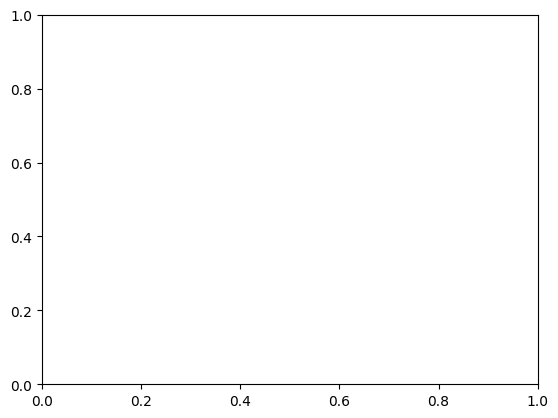

In [30]:
#topcat all matches all from 1 (the candidates catalog)
df_xmatch = df_xmatch.rename(columns={"pmRA":"pmra", "pmDEC":"pmdec","ra_1":"ra","dec_1":"dec"})
df_xmatch = df_xmatch.loc[df_xmatch["fits_name"].notna()].reset_index(drop=True)
Sources_no_uniques_5arcsec = len(df_xmatch.loc[df_xmatch["GroupID"].notna()])
Fuente_gaia_en_Groupid = (df_xmatch.loc[df_xmatch["GroupID"].notna()].groupby("GroupID")["source_id"].nunique() > 1).any()
source_con_mas_de_un_espectro = df_xmatch.loc[df_xmatch["GroupID"].notna()]["source_id"].nunique()
df_xmatch_unique = df_xmatch.loc[df_xmatch["GroupID"].isna()].reset_index(drop=True)
df_xmatch_repeated = df_xmatch.loc[df_xmatch["GroupID"].notna()].reset_index(drop=True)

fig, ax = plt.subplots()
for i in range(len(df_xmatch_unique)):
        plot_group_unique(df_xmatch_repeated,df_xmatch_repeated["source_id"][i], ax,"table")

/tmp/ipykernel_13644/2031934951.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_var.loc[constain,"constain"] = 1


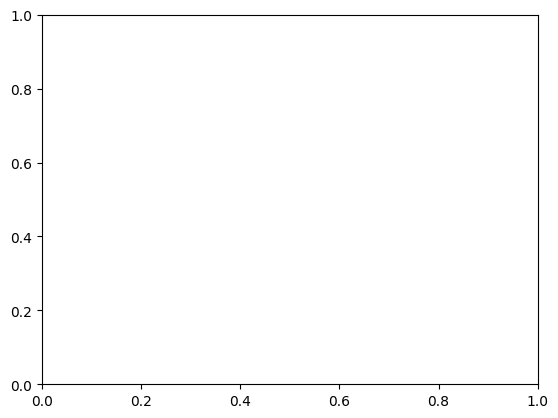

In [31]:
fig, ax = plt.subplots()
for i in range(len(df_xmatch_unique)):
        plot_group_unique(df_xmatch_unique,df_xmatch_unique["source_id"][i], ax,"table")

In [32]:
df_xmatch_repeated = df_xmatch_repeated.loc[df_xmatch_repeated["constain"]==1]
df_xmatch_unique = df_xmatch_unique.loc[df_xmatch_unique["constain"]==1]
df_xmatch_repeated['num_espectros'] = df_xmatch_repeated.groupby('index')['index'].transform('count')

In [33]:
df_xmatch = pd.concat([df_xmatch_repeated,df_xmatch_unique])

In [34]:
df_xmatch.loc[df_xmatch["num_espectros"].isna(),"num_espectros"] = 1

In [36]:
df_xmatch.to_csv("Fainter_stars/df_fainter_Lamost_Contain_Rectangle.csv",index=False)

In [1]:
import pandas as pd

In [5]:
df_information = pd.read_csv("Fainter_stars/df_fainter_Lamost_Contain_Rectangle.csv")

In [6]:
df_information = df_information.rename(columns={"predic":"B2_cut_probability"})

In [7]:
for key in list(lines.keys()):
    detection = f'{key}_type'
    EW_name = f'{key}_EW'
    fitting_name = f'{key}_fit'
    df_information[[EW_name,detection,fitting_name]] = df_information.parallel_apply(
            lambda row: main_function(
            row["fits_name"],
            row["HELIO_RV"],
            row["B2_cut_probability"],
            lines[key]["continuum_blue"],
            lines[key]["continuum_red"],
            lines[key]["spectral_line"],
            lines[key]["central_lambda"],
            5
        ),
        axis=1,
        result_type="expand")

In [8]:
df_information = df_information.loc[df_information["He I 4144_EW"]!="error"]


In [9]:
key = "He I 4471"
df_information[["THeI4471","TMgII4481"]]= df_information.parallel_apply(
            lambda row: main_HeIMgII(
            row["fits_name"],
            row["HELIO_RV"],
            row["B2_cut_probability"],
            lines[key]["continuum_blue"],
            lines[key]["continuum_red"],
            lines[key]["spectral_line"],
            lines[key]["central_lambda"],
            5
        ),
        axis=1,result_type="expand")
teoric_He_over_Mg = df_information["THeI4471"]/ df_information["TMgII4481"]

In [10]:
df_information["BHeMg"] = df_information["He I 4471_EW"] / df_information["Mg II 4481_EW"] 
df_information["THeMg"] =  teoric_He_over_Mg

#df_information = df_information.sort_values(by="SNRG",ascending=False).drop_duplicates(subset="source_id")
lamost =  df_information.loc[df_information["SNRG"]>50].reset_index(drop=True)

lamost["sp"] = np.nan

In [11]:
lamost.loc[((lamost["He II 4686_type"]=="abs")&(lamost["He II 4541_type"]=="abs")),"sp"] = "O-B0"
lamost.loc[(lamost["He I 4471_type"]=="U")&
                    (lamost["Mg II 4481_type"]!="U") &
                    (lamost["sp"].isna()),"sp"] = "Later"
lamost.loc[(lamost["He I 4471_type"]!="U")&
                    (lamost["Mg II 4481_type"]=="U") &
                    (lamost["sp"].isna()),"sp"] = "B0-B3"
lamost.loc[(lamost["He I 4471_type"]!="U")&
            (lamost["Mg II 4481_type"]=="U")&
            (lamost["He I 4144_type"]=="U")&
                (lamost["sp"].isna()),"sp"] = "B4-B7"
lamost.loc[(lamost["THeMg"] >= 3)&
                    (lamost["He I 4144_type"]=="abs") &
                    (lamost["sp"].isna()),"sp"] = "B0-B3"
lamost.loc[(lamost["THeMg"] > 1)&
                    (lamost["He I 4144_type"]=="abs") &
                    (lamost["sp"].isna()),"sp"] = "B4-B7"
lamost.loc[(lamost["THeMg"] <= 1)&
                    (lamost["He I 4144_type"]=="abs") &
                    (lamost["sp"].isna()),"sp"] = "B8-A1"
lamost.loc[(lamost["THeMg"] > 1)&
                    (lamost["He I+He II 4026_type"]=="abs") &
                   ( (lamost["Fe II 4233_type"]=="U")|(lamost["Fe II 4233_EW"]<=0.15))&
                    (lamost["sp"].isna()),"sp"] = "B4-B7"
lamost.loc[(lamost["THeMg"] <= 1)&
                    (lamost["He I+He II 4026_type"]=="abs") &
                     ( (lamost["Fe II 4233_type"]=="U")|(lamost["Fe II 4233_EW"]<=0.15))&
                    (lamost["sp"].isna()),"sp"] = "B8-A1"

lamost.loc[(lamost["He I 4144_type"]!="abs") &
                    (lamost["He I+He II 4026_type"]!="abs") &
                    (lamost["sp"].isna()),"sp"] = "Later"

lamost.loc[(lamost["He I 4144_type"]!="abs") &
                    (lamost["He I+He II 4026_type"]=="abs") &
                    (lamost["Fe II 4233_EW"]>0.15)&
                    (lamost["sp"].isna()),"sp"] = "Later"

/tmp/ipykernel_19900/2658578078.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'O-B0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  lamost.loc[((lamost["He II 4686_type"]=="abs")&(lamost["He II 4541_type"]=="abs")),"sp"] = "O-B0"


In [12]:
bins = [0.6, 0.7, 0.8, 0.9, 1.0]
labels = ['0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1.0']

# Crear una nueva columna con los bins
lamost['prob_bin'] = pd.cut(lamost['B2_cut_probability'], bins=bins, labels=labels, right=True)

# Agrupar por 'prob_bin' y 'sp', y contar las ocurrencias
counts = lamost.groupby(['prob_bin', 'sp']).size().unstack(fill_value=0)

/tmp/ipykernel_19900/2910963396.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = lamost.groupby(['prob_bin', 'sp']).size().unstack(fill_value=0)


In [31]:
lamost.loc[lamost["sp"].notna()].to_csv("")

,index,source_id,ra,dec,ra_error,dec_error,parallax,parallax_error,parallax_over_error,pmra,...,He II 4541_fit,He II 4686_EW,He II 4686_type,He II 4686_fit,THeI4471,TMgII4481,BHeMg,THeMg,sp,prob_bin
0,1036525,3344969767629935872,94.564103,15.131559,0.013989,0.012570,0.207932,0.015265,13.621370,0.076710,...,E,0.371034,abs,E,0.865215,0.083557,NaN,10.354727,O-B0,0.7-0.8
1,287852,3432192620609959424,95.582472,26.322291,0.016248,0.016083,0.168113,0.019863,8.463581,0.372942,...,U,-0.158132,ems,E,1.346027,0.249778,NaN,5.388890,B0-B3,0.6-0.7
2,1069052,187250236123135360,78.358294,37.446243,0.011038,0.005866,0.379523,0.013284,28.570229,0.362976,...,E,0.720021,abs,E,0.865089,0.124296,NaN,6.959936,O-B0,0.7-0.8
3,1069052,187250236123135360,78.358294,37.446243,0.011038,0.005866,0.379523,0.013284,28.570229,0.362976,...,E,0.562586,abs,E,0.706146,-0.036426,NaN,-19.385505,O-B0,0.7-0.8
4,1058108,272076905372370816,67.321024,52.573968,0.012255,0.009211,0.228556,0.016344,13.983782,0.160288,...,E,NaN,U,U,1.026624,0.150733,NaN,6.810866,B0-B3,0.6-0.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2783,1070929,276177740147705856,61.682046,54.396639,0.009358,0.006703,0.153486,0.012223,12.556896,-0.904266,...,E,0.277911,abs,E,0.363771,0.036607,NaN,9.937080,O-B0,0.6-0.7
2784,1072999,1865673736869022848,313.683528,32.065368,0.013513,0.017924,0.102693,0.023883,4.299868,-0.964754,...,U,NaN,U,U,1.006104,0.199546,6.717970,5.041954,B0-B3,0.8-0.9
2785,1073164,187564112333470592,79.754118,38.086690,0.012099,0.009023,0.360599,0.013782,26.165401,-0.073219,...,E,NaN,U,U,1.107287,0.231886,1.579343,4.775133,B4-B7,0.6-0.7
2786,1073392,3403667578134303616,82.632269,21.169298,0.020856,0.015111,0.146817,0.022331,6.574629,1.085110,...,U,NaN,U,U,-0.012333,0.032644,0.345881,-0.377817,B8-A1,0.6-0.7


In [25]:
(lamost["sp"]=="B")(lamost["sp"]=="B4-B7")

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2182000181.py, line 1)

/tmp/ipykernel_13644/917612631.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = lamost.groupby(['prob_bin', 'sp']).size().unstack(fill_value=0)
/tmp/ipykernel_13644/917612631.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  detections = lamost.groupby('prob_bin')['masiva'].agg(total='count', unos='sum')


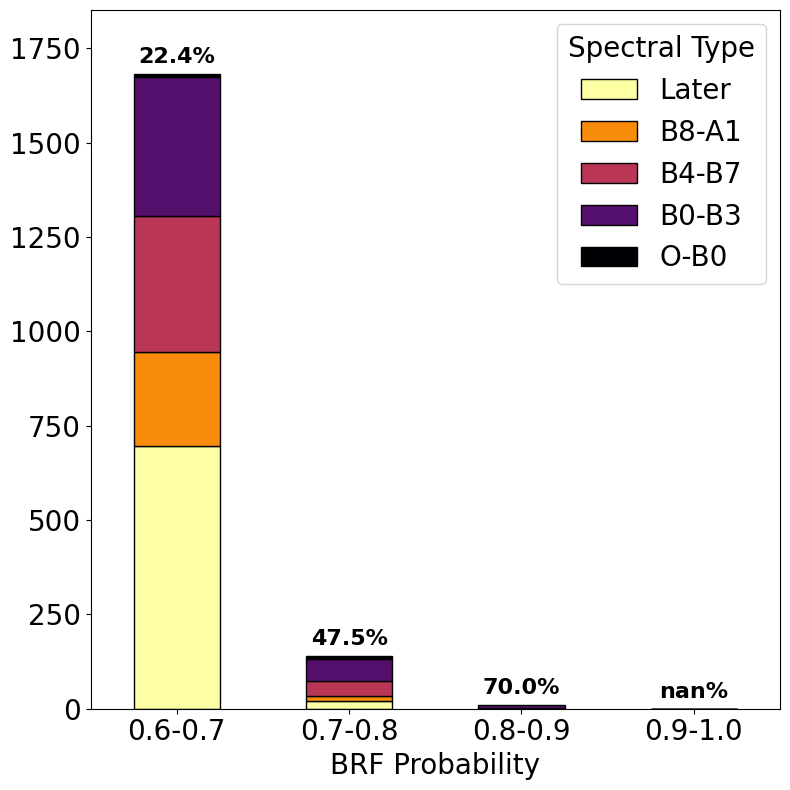

In [79]:
.import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Definir los bins y las etiquetas
bins = [0.6, 0.7, 0.8, 0.9, 1.0]
labels = ['0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1.0']

# Crear una nueva columna con los bins
lamost['prob_bin'] = pd.cut(lamost['B2_cut_probability'], bins=bins, labels=labels, right=True)

# Agrupar por 'prob_bin' y 'sp', y contar las ocurrencias
counts = lamost.groupby(['prob_bin', 'sp']).size().unstack(fill_value=0)

counts = counts[["Later", "B8-A1", "B4-B7", "B0-B3", "O-B0"]]

# Calcular el total y los 'unos' por bin de probabilidad
detections = lamost.groupby('prob_bin')['masiva'].agg(total='count', unos='sum')

# Calcular el porcentaje de detección
detections['porcentaje'] = (detections['unos'] / detections['total']) * 100

# Crear el gráfico de barras apiladas
fig, ax = plt.subplots(figsize=(8, 8))

# Obtener los colores para las categorías de 'sp'
colors = plt.cm.inferno_r(np.linspace(0, 1, counts.shape[1]))

# Dibujar las barras apiladas
counts.plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='black')

# Ajustar los límites del eje y
ax.set_ylim(0, counts.values.sum(axis=1).max() * 1.1)

# Agregar el porcentaje de detección al lado derecho de cada barra
for idx, (bin_label, row) in enumerate(counts.iterrows()):
    total = row.sum()
    porcentaje = detections.loc[bin_label, 'porcentaje']
    x = idx
    y = total
    ax.text(x, y + (ax.get_ylim()[1] * 0.01), f'{porcentaje:.1f}%', ha='center', va='bottom', fontsize=16, fontweight='bold')

# Configurar etiquetas y título
ax.set_xlabel('BRF Probability', fontsize=20)
ax.set_ylabel('', fontsize=16)

# Mover la leyenda fuera del gráfico
ax.legend(title='Spectral Type', fontsize=20, title_fontsize=20)

# Ajustar el tamaño de las etiquetas del eje x e y
ax.tick_params(axis='x', labelsize=20)  # Aumentar el tamaño de los ticks del eje x
ax.tick_params(axis='y', labelsize=20)  # Aumentar el tamaño de los ticks del eje y

# Ajustar las etiquetas del eje x
plt.xticks(rotation=0)

# Ajustar el diseño
plt.tight_layout()

#plt.savefig(f"{path_plots}/Detection_rate.pdf", format='pdf', bbox_inches='tight')
# Mostrar el gráfico
plt.show()



## Interpretations of the results

In [12]:
#https://svo2.cab.inta-csic.es/theory/fps/index.php?id=2MASS/2MASS.H&&mode=search&search_text=2mass%20h#filter

def compute_H_minus_G(files_kurucz):
    zero_point_2mass = 1.11933e-10
    zero_point_Gaia = 2.50386e-9
    mag_diff = []
    for files in files_kurucz:
        df_var = pd.read_csv(files, delimiter="\t", comment="#", names=["filter", "lambda", "flux", "_"])
        H_mag = -2.5 * np.log10((df_var["flux"][0] / zero_point_2mass))
        G_mag = -2.5 * np.log10((df_var["flux"][1] / zero_point_Gaia))
        mag_diff_kurucz = H_mag - G_mag
        print(df_var["flux"][0])
        mag_diff.append(mag_diff_kurucz)
    return mag_diff

In [3]:
files_kurucz = glob.glob("Kurucz2003_phot_1745851039.8092/*")

In [17]:
df_var = pd.read_csv(files_kurucz[0], delimiter="\t", comment="#", names=["filter", "lambda", "flux", "_"])


In [25]:
files_kurucz[0]

'Kurucz2003_phot_1745851039.8092/Kurucz2003_fp00t49000g45k2odfnew.fl.phot.dat'

In [27]:
-2.5*np.log10(12829651.3843/1.11933e-10)

-42.64814177958328

In [4]:
df =  pd.DataFrame()
df["teff"] = pd.DataFrame(files_kurucz)[0].str.split("/").str[-1].str.split("t").str[1].str.split("g").str[0].astype(float)

In [13]:
df["H-G"] = compute_H_minus_G(files_kurucz)

12829651.3843
9332426.2034093
2100398.9636311
1641359.05879
8654669.0272425
7725272.1551051
3055293.6550258
2055658.2134445
1789232.0505141
2202634.0808167
3381137.4323787
1675054.7075171
2479979.5082382
2098256.4924087
1723811.6251095
2440872.8363701
4792192.1693353
12729815.594999
2214620.1105757
1680365.8206086
5350951.5310431
12059844.777299
4500496.5240793
7927780.9545804
1998940.0455068
2460471.945779
2161125.1082159
3286046.2972417
4670136.8672367
3174597.7234693
2206472.3599984
1892368.8457438
2497531.3563078
5805646.177754
1901503.5442804
3788792.7483775
7121553.123921
11012429.818937
1655790.7227321
6102460.1538157
6237062.8138444
2102658.6327307
2370533.9774973
1945292.9422637
2951819.1893016
10749178.706812
3365060.352832
11725310.628429
4434771.2175617
9710711.386328
4021359.4659749
4974927.7907989
10679232.63661
1994234.7924924
2739460.6029798
1740128.7630727
1547141.0268371
3947500.5697635
11536208.294308
1672105.3773444
4633274.5652593
7394858.43158
2415380.6168651
1913

Text(0.5, 1.0, 'Kurucz2003')

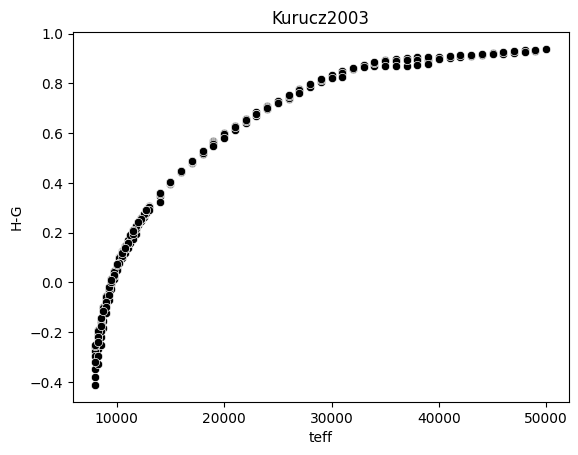

In [6]:
sns.scatterplot(data=df,x="teff",y="H-G",color="black")
plt.xlabel("teff")
plt.title("Kurucz2003")

In [7]:
files_tlusty = glob.glob("tlusty_mergedbin_phot_1745850943.8995/*")
df_2 =  pd.DataFrame()
df_2["teff"] = pd.DataFrame(files_tlusty)[0].str.split("/").str[-1].str.split("t").str[3].str.split(".").str[0].astype(float)

In [8]:
df_2["H-G"] = compute_H_minus_G(files_tlusty)

Text(0.5, 1.0, 'tlusty')

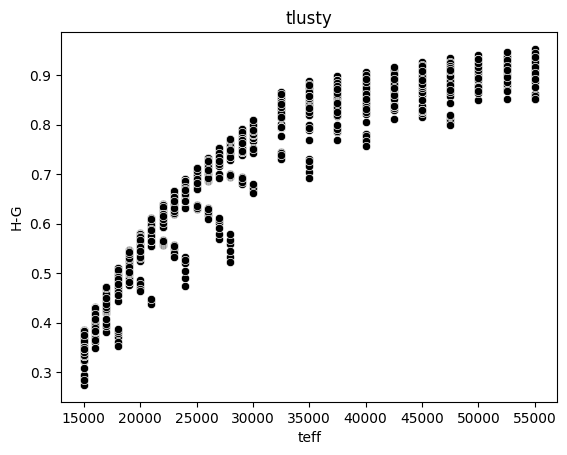

In [9]:
sns.scatterplot(data=df_2,x="teff",y="H-G",color="black")
plt.xlabel("teff")
plt.title("tlusty")